# UNO Symbol Classifier: Deep Learning Design And Interpretability

This notebook focuses only on the deep learning part of the project: the CNN used to classify cropped UNO symbols. The goal is to justify the model design and then show, with several interpretability views, what the network has learned.

The notebook is organized as a guided walkthrough. Each code cell is introduced right before it so the purpose of every output is explicit.


## Cell 1: Imports And Setup

This cell prepares the notebook environment.

It does four things:

- locates the project root whether the notebook is opened from the repository root or from the project folder,
- adds `src/` to `sys.path` so local modules can be imported,
- imports the training-history and interpretability helpers,
- and fixes the random seed so sampling, embeddings, and Grad-CAM examples stay reproducible.

The output of this cell is empty by design: it only initializes the notebook.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import torch

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = Path.cwd() / "project" / "final_group_69_gr_69"

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cnn import DEFAULT_MODEL_PATH
from notebook_utils import DEFAULT_HISTORY_PATH, load_history, plot_confusion_matrix, plot_history
from interpretability import (
    DEFAULT_DATASET_DIR,
    build_symbol_datasets,
    classifier_summary,
    collect_predictions,
    confusion_matrix_from_predictions,
    extract_embeddings,
    extract_intermediate_activations,
    find_example_index_for_label,
    load_classifier_components,
    load_split_labels,
    plot_embedding_projection,
    plot_first_layer_filters,
    plot_gradcam_examples,
    plot_intermediate_activations,
    plot_symbol_samples,
    project_embeddings,
    set_seed,
    split_class_counts,
)

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
set_seed(42)
plt.rcParams["figure.dpi"] = 120

## Cell 2: Load The Saved Model And Dataset Metadata

This cell loads everything needed for the analysis:

- the saved checkpoint,
- the train and validation datasets,
- the history file saved during training,
- and summary statistics such as parameter count and split sizes.

This gives a compact factual overview before we interpret the model.


In [2]:
MODEL_PATH = DEFAULT_MODEL_PATH
DATASET_DIR = DEFAULT_DATASET_DIR
HISTORY_PATH = DEFAULT_HISTORY_PATH

model, checkpoint, device = load_classifier_components(model_path=MODEL_PATH, device="auto")
train_dataset, val_dataset, class_to_idx = build_symbol_datasets(DATASET_DIR, train_labels="train.json", val_labels="val.json")
idx_to_class = checkpoint["idx_to_class"]
history = load_history(HISTORY_PATH)

train_labels = load_split_labels(DATASET_DIR, "train.json")
val_labels = load_split_labels(DATASET_DIR, "val.json")
summary = classifier_summary(model)

print(f"Device: {device}")
print(f"Classes: {list(checkpoint['class_to_idx'].keys())}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Total parameters: {summary['total_parameters']:,}")
print(f"Best saved validation accuracy: {checkpoint.get('val_acc', 'N/A')}")
print("\nTrain split counts:")
print(split_class_counts(train_labels))
print("\nValidation split counts:")
print(split_class_counts(val_labels))

Device: cuda
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'draw_2', 'draw_4', 'reverse', 'skip', 'wild']
Training images: 9990
Validation images: 268
Total parameters: 141,423
Best saved validation accuracy: 1.0

Train split counts:
{'0': 666, '1': 666, '2': 666, '3': 666, '4': 666, '5': 666, '6': 666, '7': 666, '8': 666, '9': 666, 'draw_2': 666, 'draw_4': 666, 'reverse': 666, 'skip': 666, 'wild': 666}

Validation split counts:
{'0': 13, '1': 17, '2': 24, '3': 21, '4': 26, '5': 21, '6': 17, '7': 30, '8': 26, '9': 12, 'draw_2': 15, 'draw_4': 5, 'reverse': 15, 'skip': 15, 'wild': 11}


## Why The Design Is Reasonable

This is a structured multiclass classification problem: each sample is a single cropped UNO symbol and each crop belongs to exactly one class. That structure explains the main design choices.

- A compact CNN is enough because the visual vocabulary is small and shape-driven.
- Grayscale preprocessing removes unnecessary color variation and encourages the network to focus on geometry.
- A `64x64` input keeps enough detail for digits and action symbols while staying efficient.
- Cross-entropy is the correct loss for single-label classification.
- Rotation and translation augmentation teach orientation and alignment robustness.
- Adaptive average pooling makes the classifier less sensitive to exact symbol position in the crop.


## Cell 3: Show Representative Training Samples

Before discussing layers, it is useful to look at the actual input distribution seen by the CNN. This cell plots a few examples per class from the training set.

When reading this figure, notice that many classes differ mostly through shape details: for example curves, intersections, enclosed loops, or stroke count. This is exactly the kind of structure convolutional filters are good at learning.


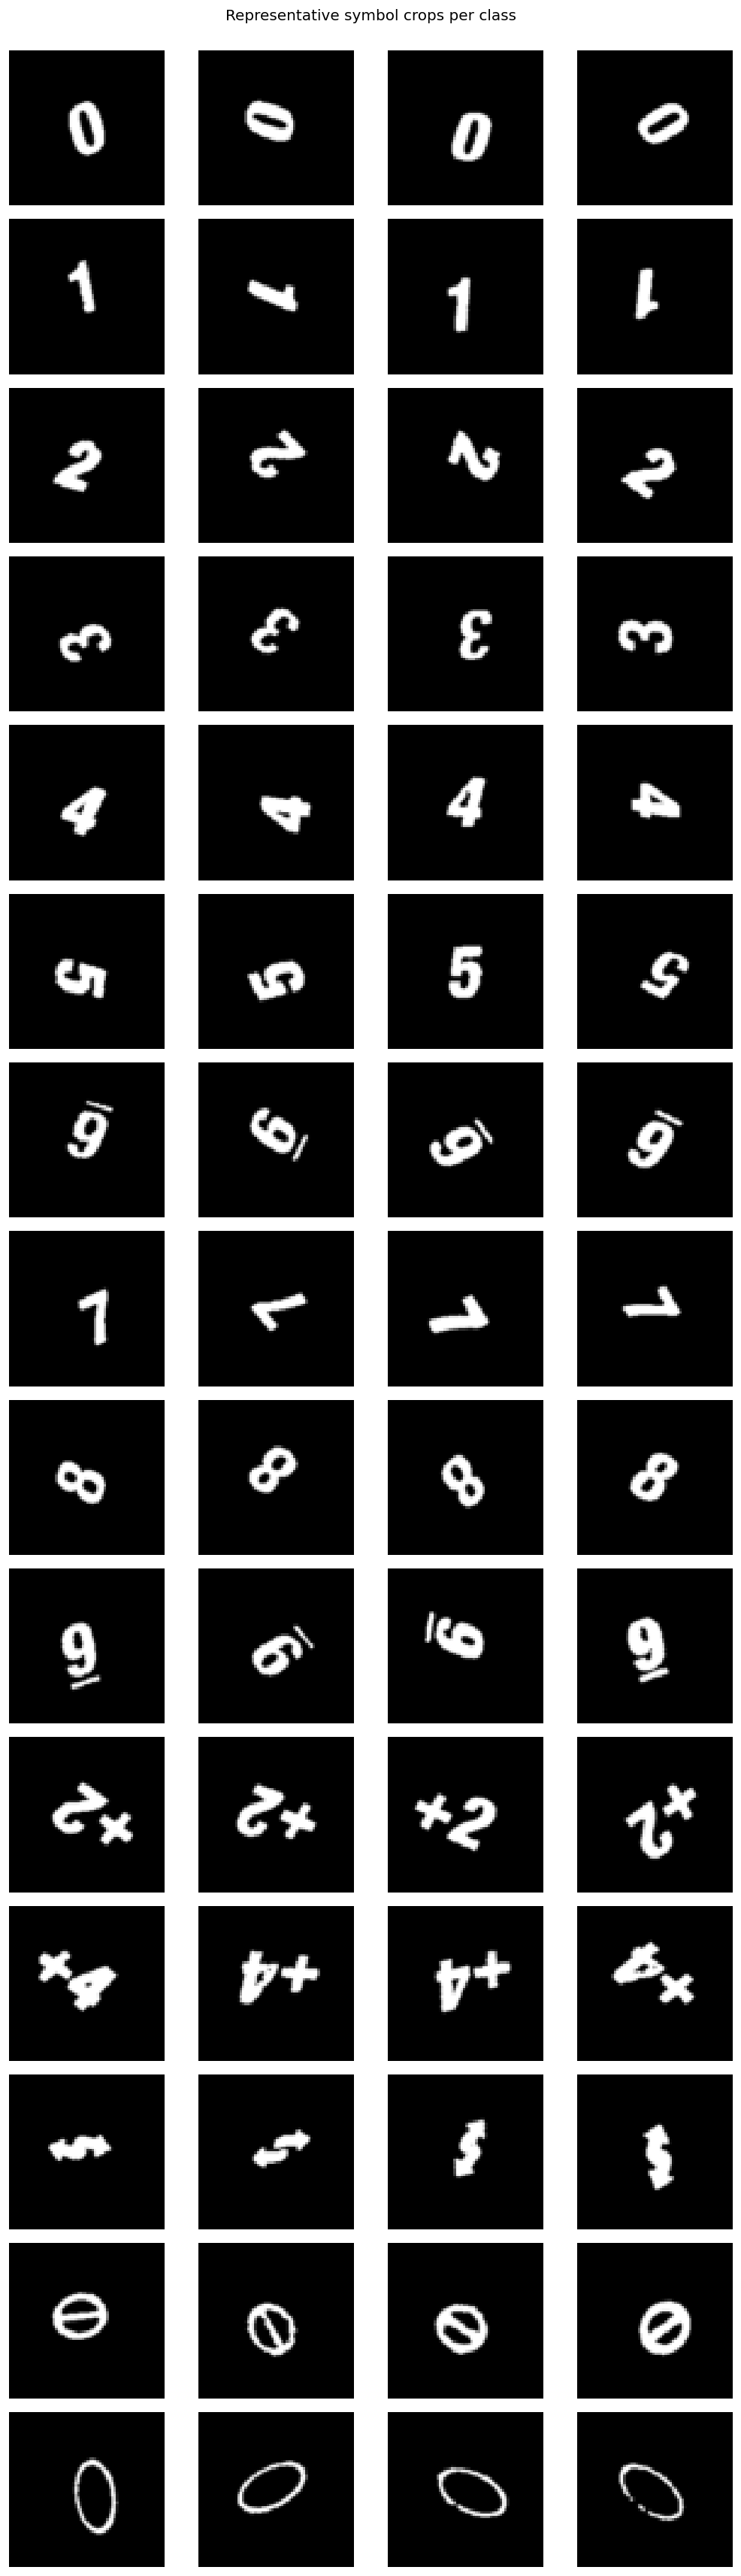

In [3]:
plot_symbol_samples(train_dataset, idx_to_class, samples_per_class=4, seed=42)

## Understanding The Network Layer By Layer

The model can be read as a progression from local visual primitives to compact semantic features.

### Early layers

The first convolutional layer receives a single grayscale channel. At this point the network can only detect very local patterns such as:

- horizontal or vertical edges,
- diagonals,
- stroke endings,
- small corners,
- and local foreground/background contrast.

These are the building blocks needed for digits and action symbols.

### Middle layers

After the first pooling step, the receptive field becomes larger. The second block can combine low-level edges into more meaningful motifs:

- curve fragments,
- repeated parallel strokes,
- crossings,
- enclosed regions,
- and more stable parts of the `reverse`, `skip`, or `draw` icons.

At this stage the network is no longer looking at isolated pixels. It is starting to represent symbol parts.

### Deeper layers

The third block works on more abstract combinations of those motifs. By then, a feature map can respond to something close to a class-specific template such as:

- the loop structure of a `0`, `6`, or `8`,
- the open-vs-closed geometry that separates some digits,
- or the larger icon arrangement of action cards.

### Final classifier

Adaptive average pooling compresses each feature map into a single summary value. That means the model asks a question like: *how strongly was this high-level feature present somewhere in the patch?* The final linear layer then combines those responses into one score per class.

This architecture is a good fit here because the important information is mostly **what patterns exist**, not their exact pixel-perfect coordinates.


## Cell 4: Print The Architecture

This cell prints the exact PyTorch model. The goal is to connect the conceptual explanation above to the concrete implementation used in training.

While reading the output, focus on three elements:

- the gradual increase in channel count (`32 -> 64 -> 128`),
- the periodic max-pooling that reduces spatial size,
- and the very small classifier head, which shows that most of the learning happens in the convolutional feature extractor.


In [4]:
print(model)

SymbolCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1,

## Seeing The Image Between Layers

The previous section explained conceptually what each stage should learn. The next cells make that concrete by showing **intermediate activations** for real input symbols.

How to read these plots:

- The first row is the original input symbol.
- For each later stage, the leftmost image is the **mean activation map** across channels. This gives a coarse summary of where the network is focusing.
- The remaining images are the individual channels at that stage. Each one can be thought of as one learned detector.

These are not reconstructed images in pixel space. They are feature maps, so bright regions indicate stronger responses to learned patterns.


## Cell 6: Choose Example Symbols For Intermediate Activations

This cell selects one or two validation examples that we will reuse for the layer-by-layer visualization.

You can change `example_label_1` or `example_label_2` to any available class such as `"0"`, `"8"`, `"skip"`, or `"reverse"` if you want to inspect a different symbol.


In [14]:
example_label_1 = "7"
example_label_2 = "draw_4"

example_index_1 = find_example_index_for_label(val_dataset, idx_to_class, example_label_1)
example_index_2 = find_example_index_for_label(val_dataset, idx_to_class, example_label_2)

print("example 1 index:", example_index_1, "label:", example_label_1)
print("example 2 index:", example_index_2, "label:", example_label_2)


example 1 index: 7 label: 7
example 2 index: 9 label: draw_4


## Cell 7: Visualize Intermediate Activations For Example 1

This cell pushes one validation symbol through the CNN and records activations after the main stages of the feature extractor.

A typical pattern to look for is:

- early layers respond to edges and local stroke fragments,
- middle layers respond to larger curved or repeated structures,
- deeper layers become sparse and selective, often highlighting only the most class-relevant parts of the symbol.


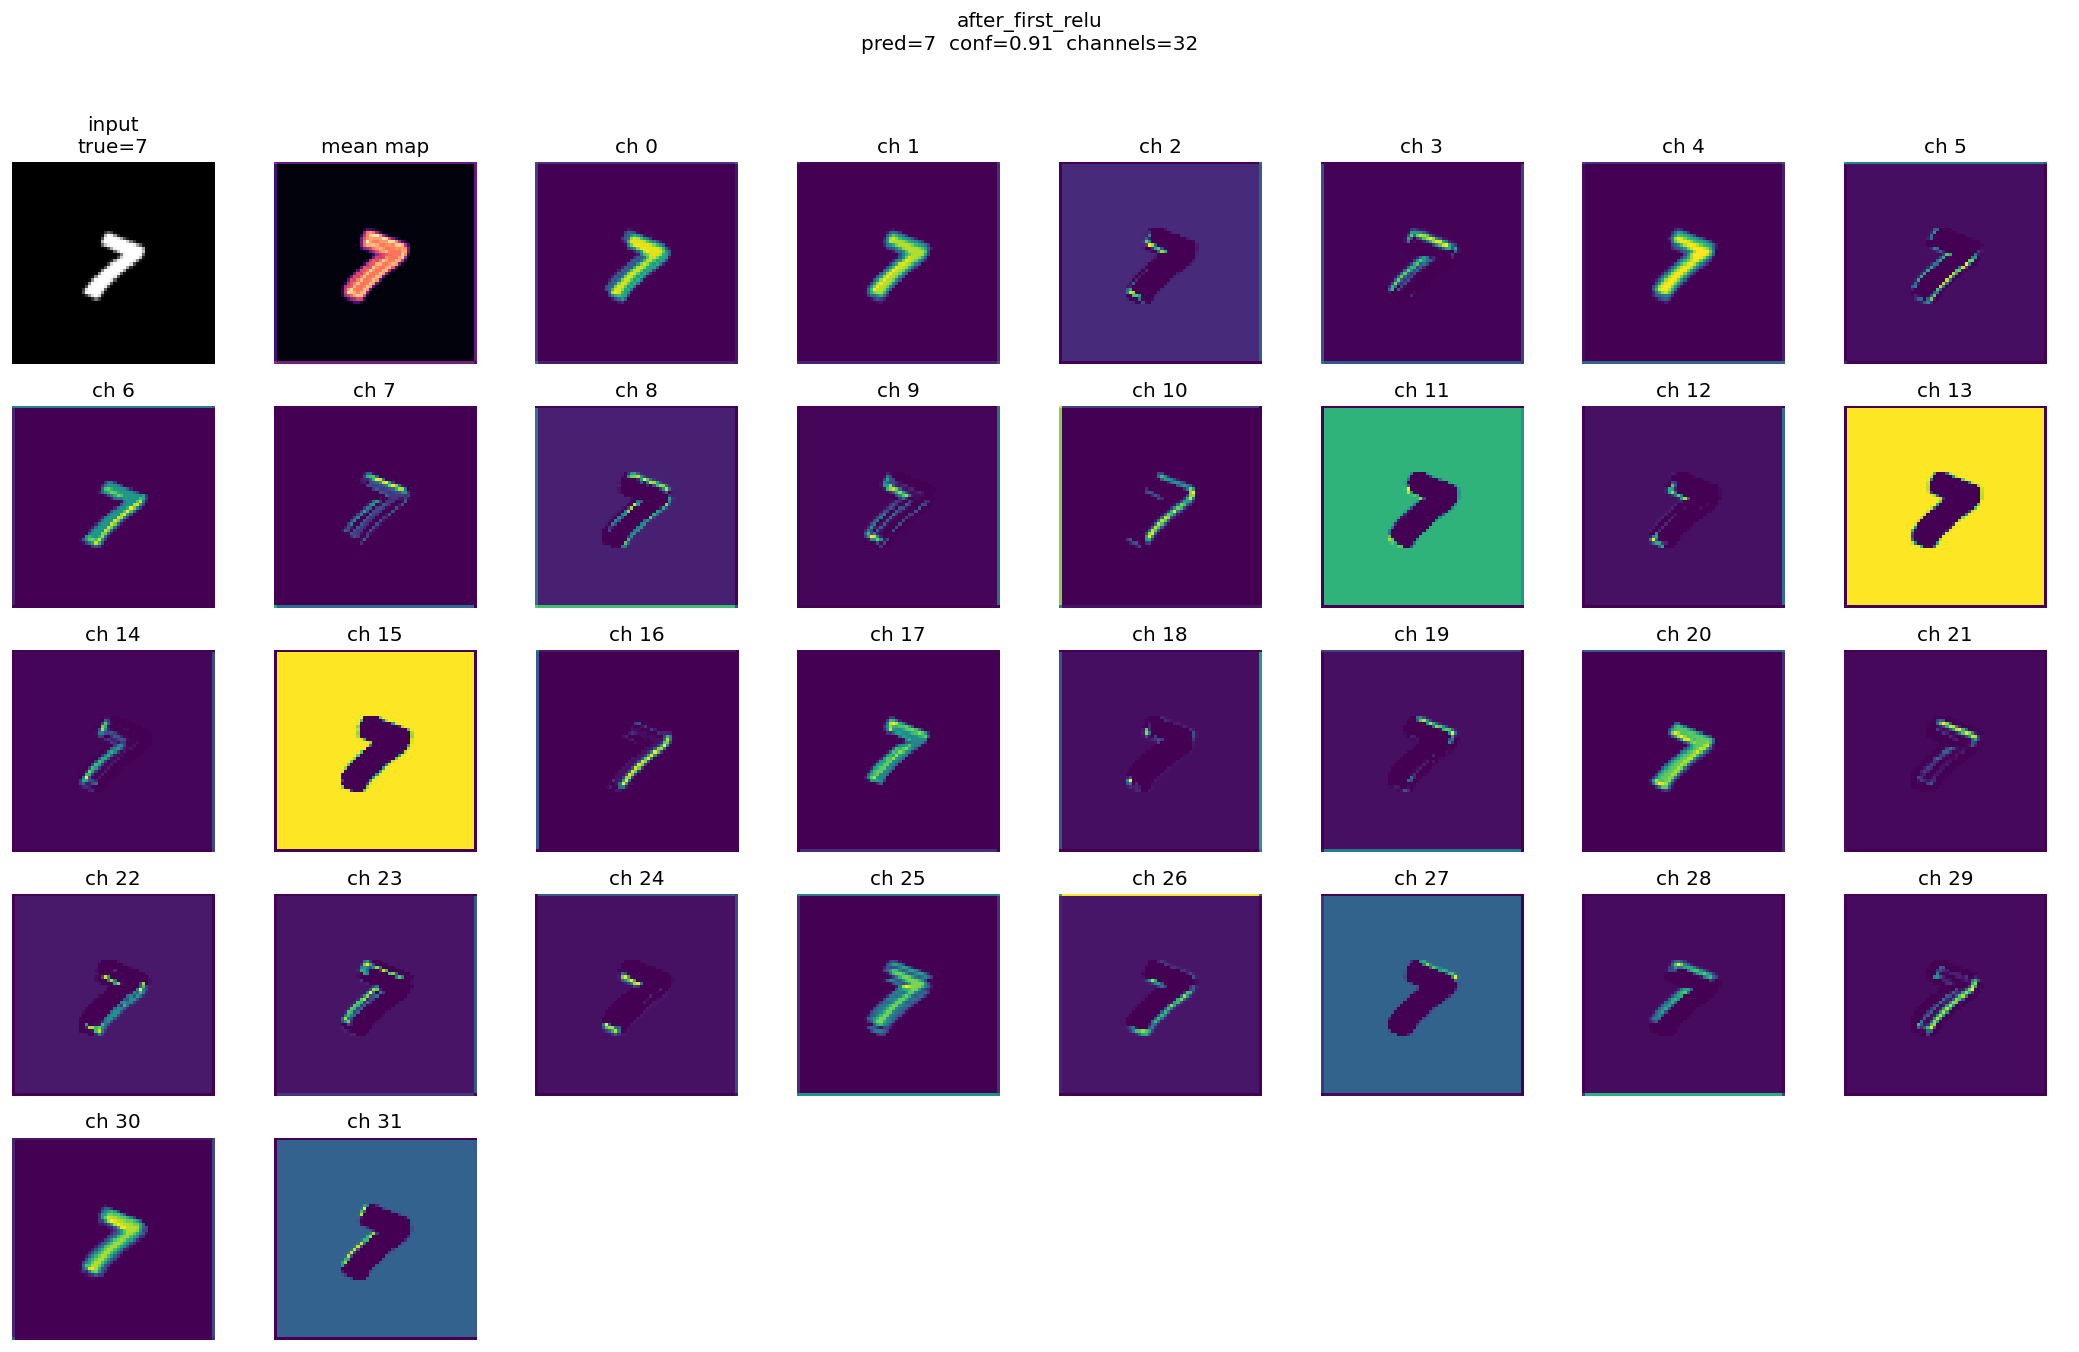

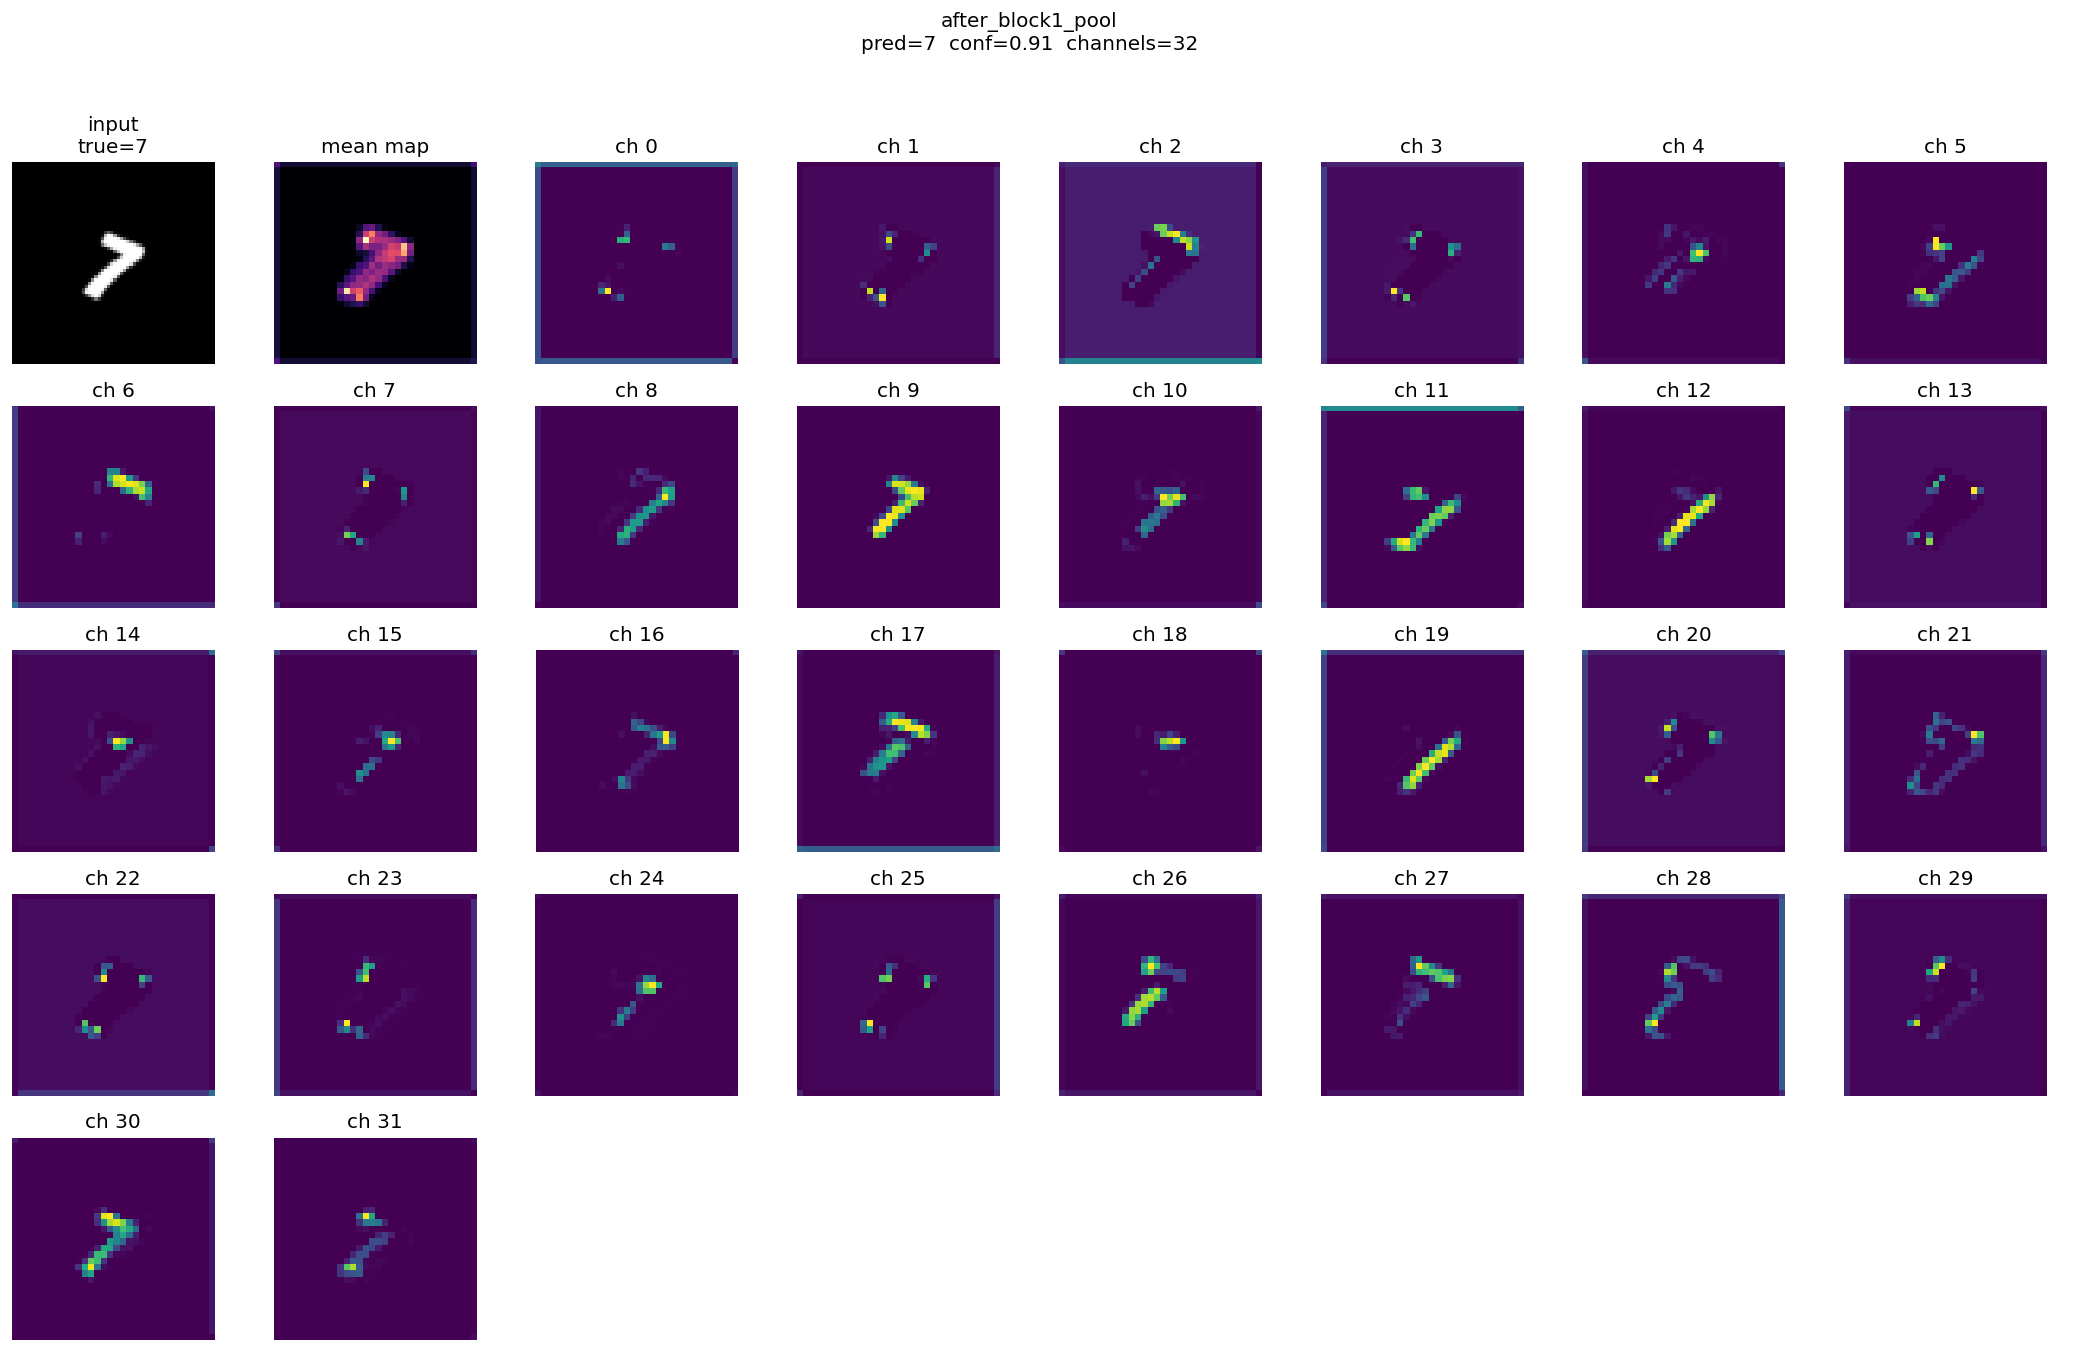

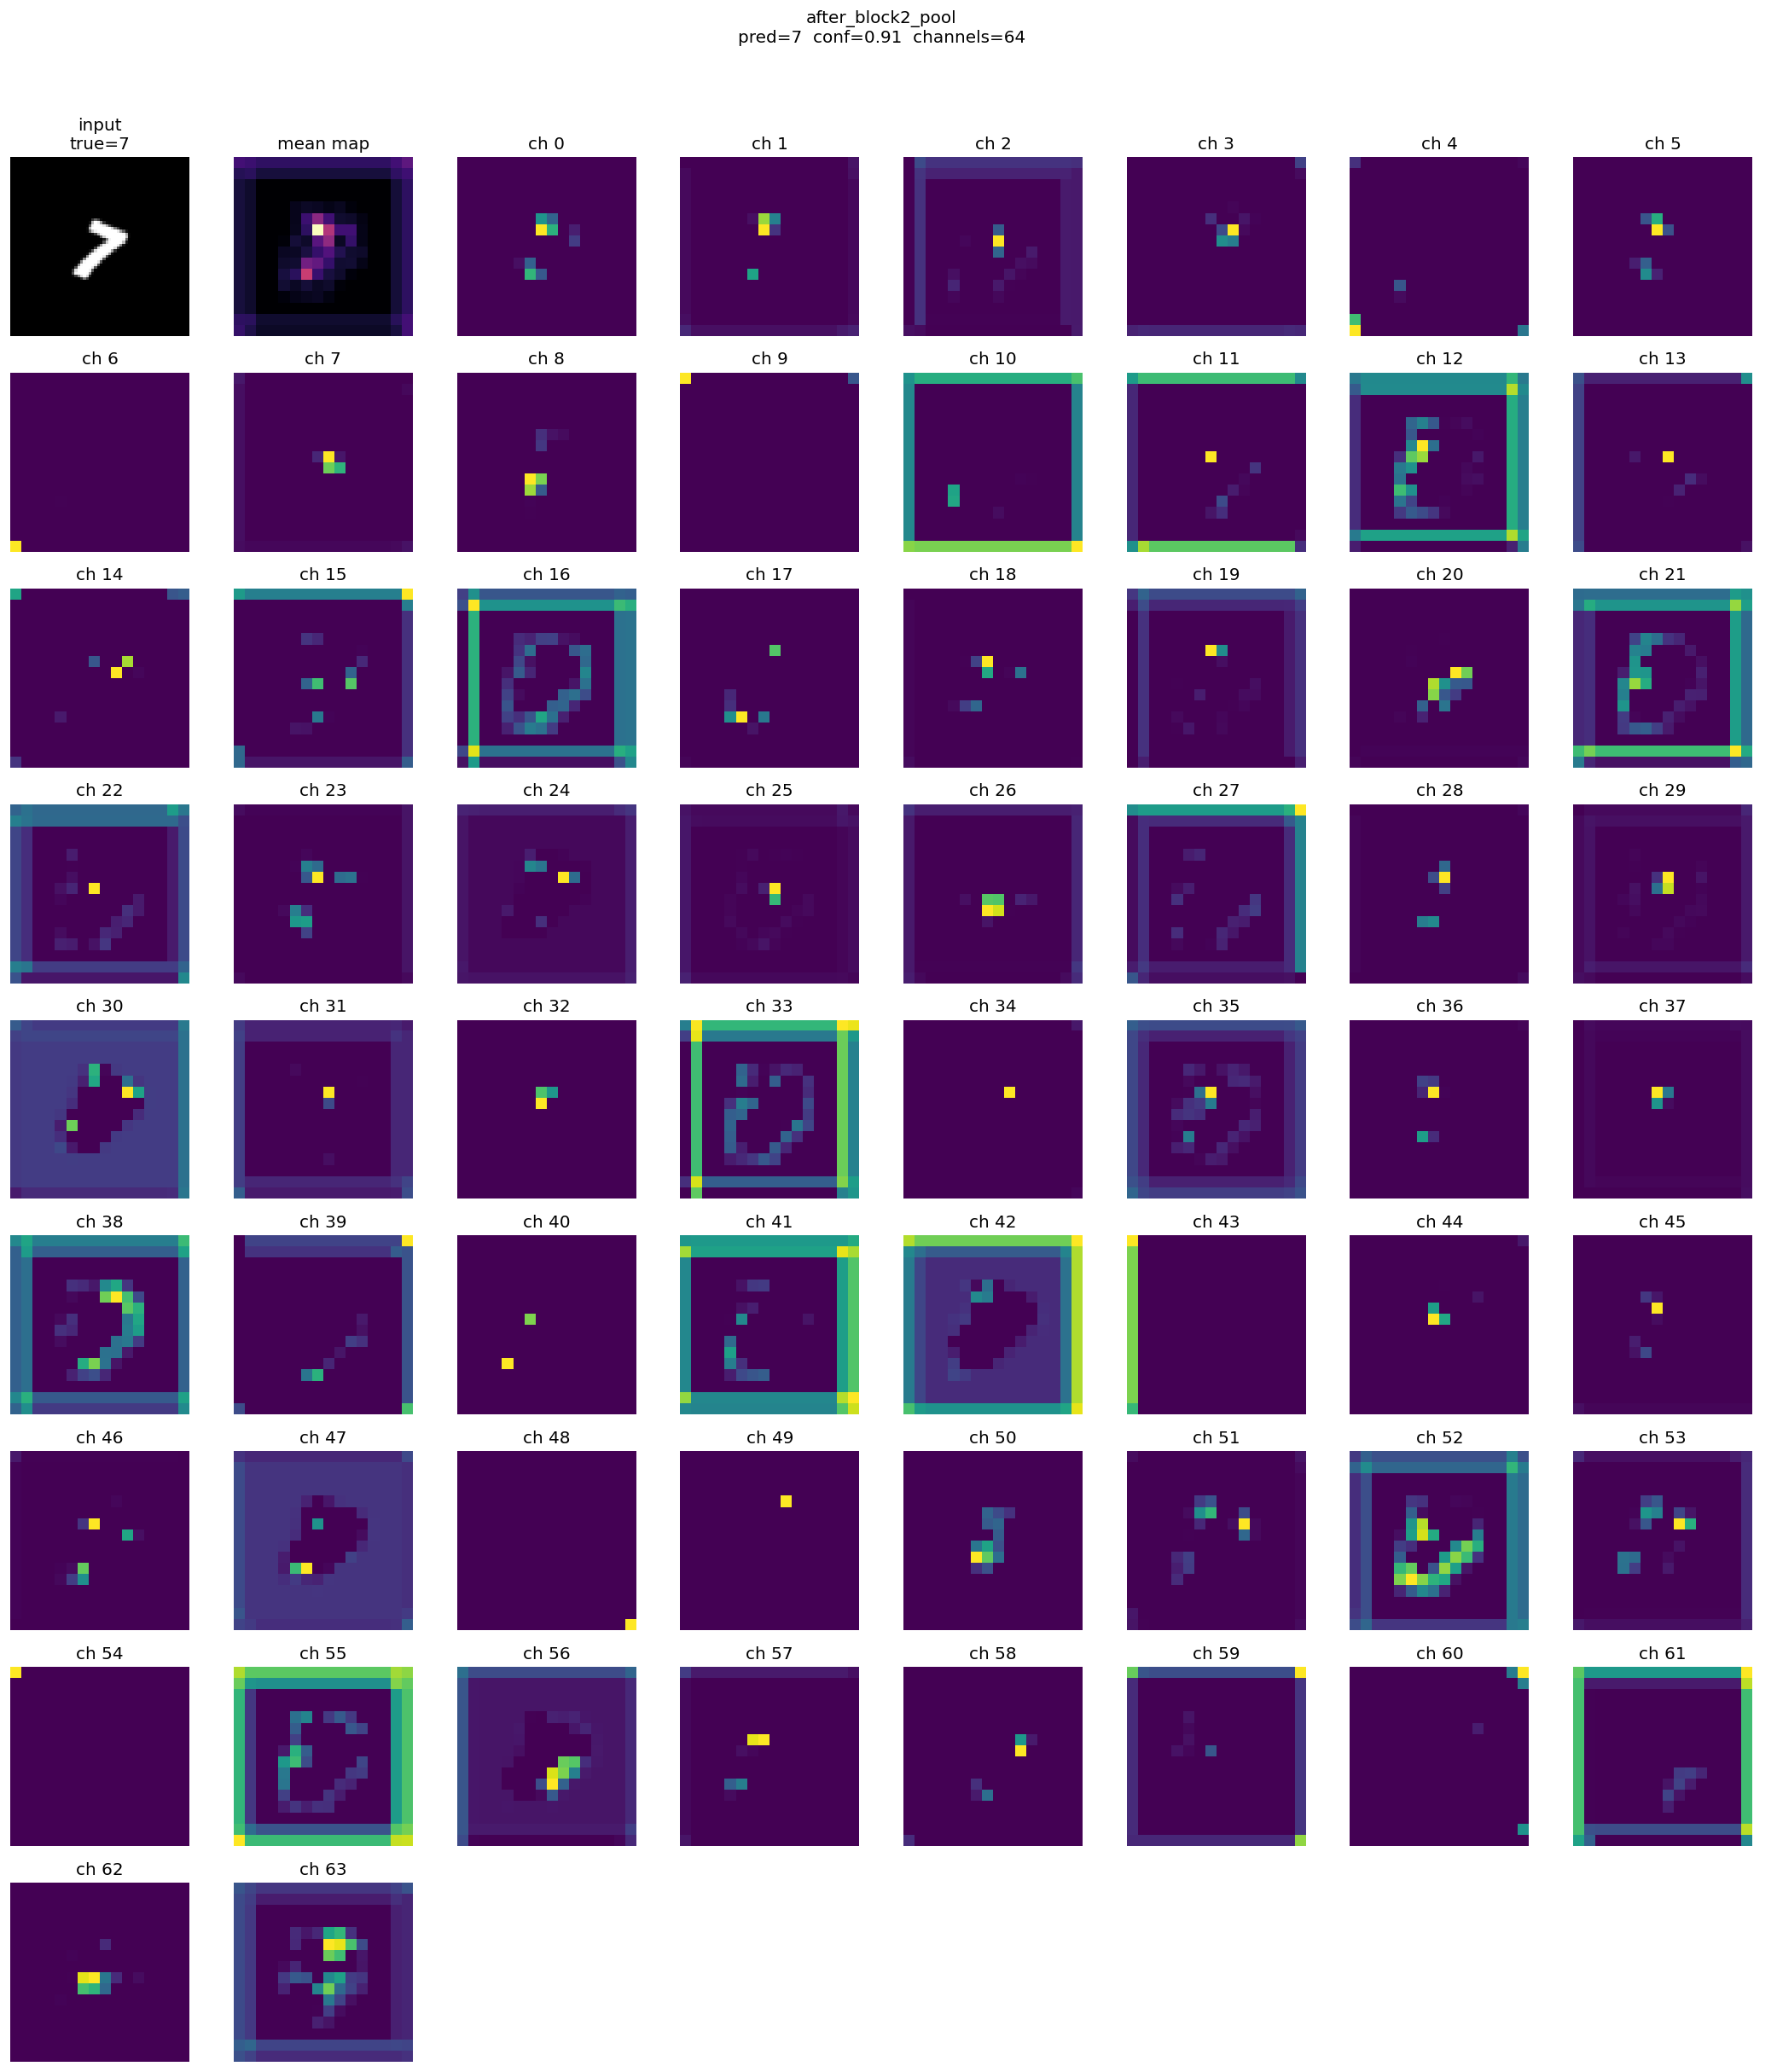

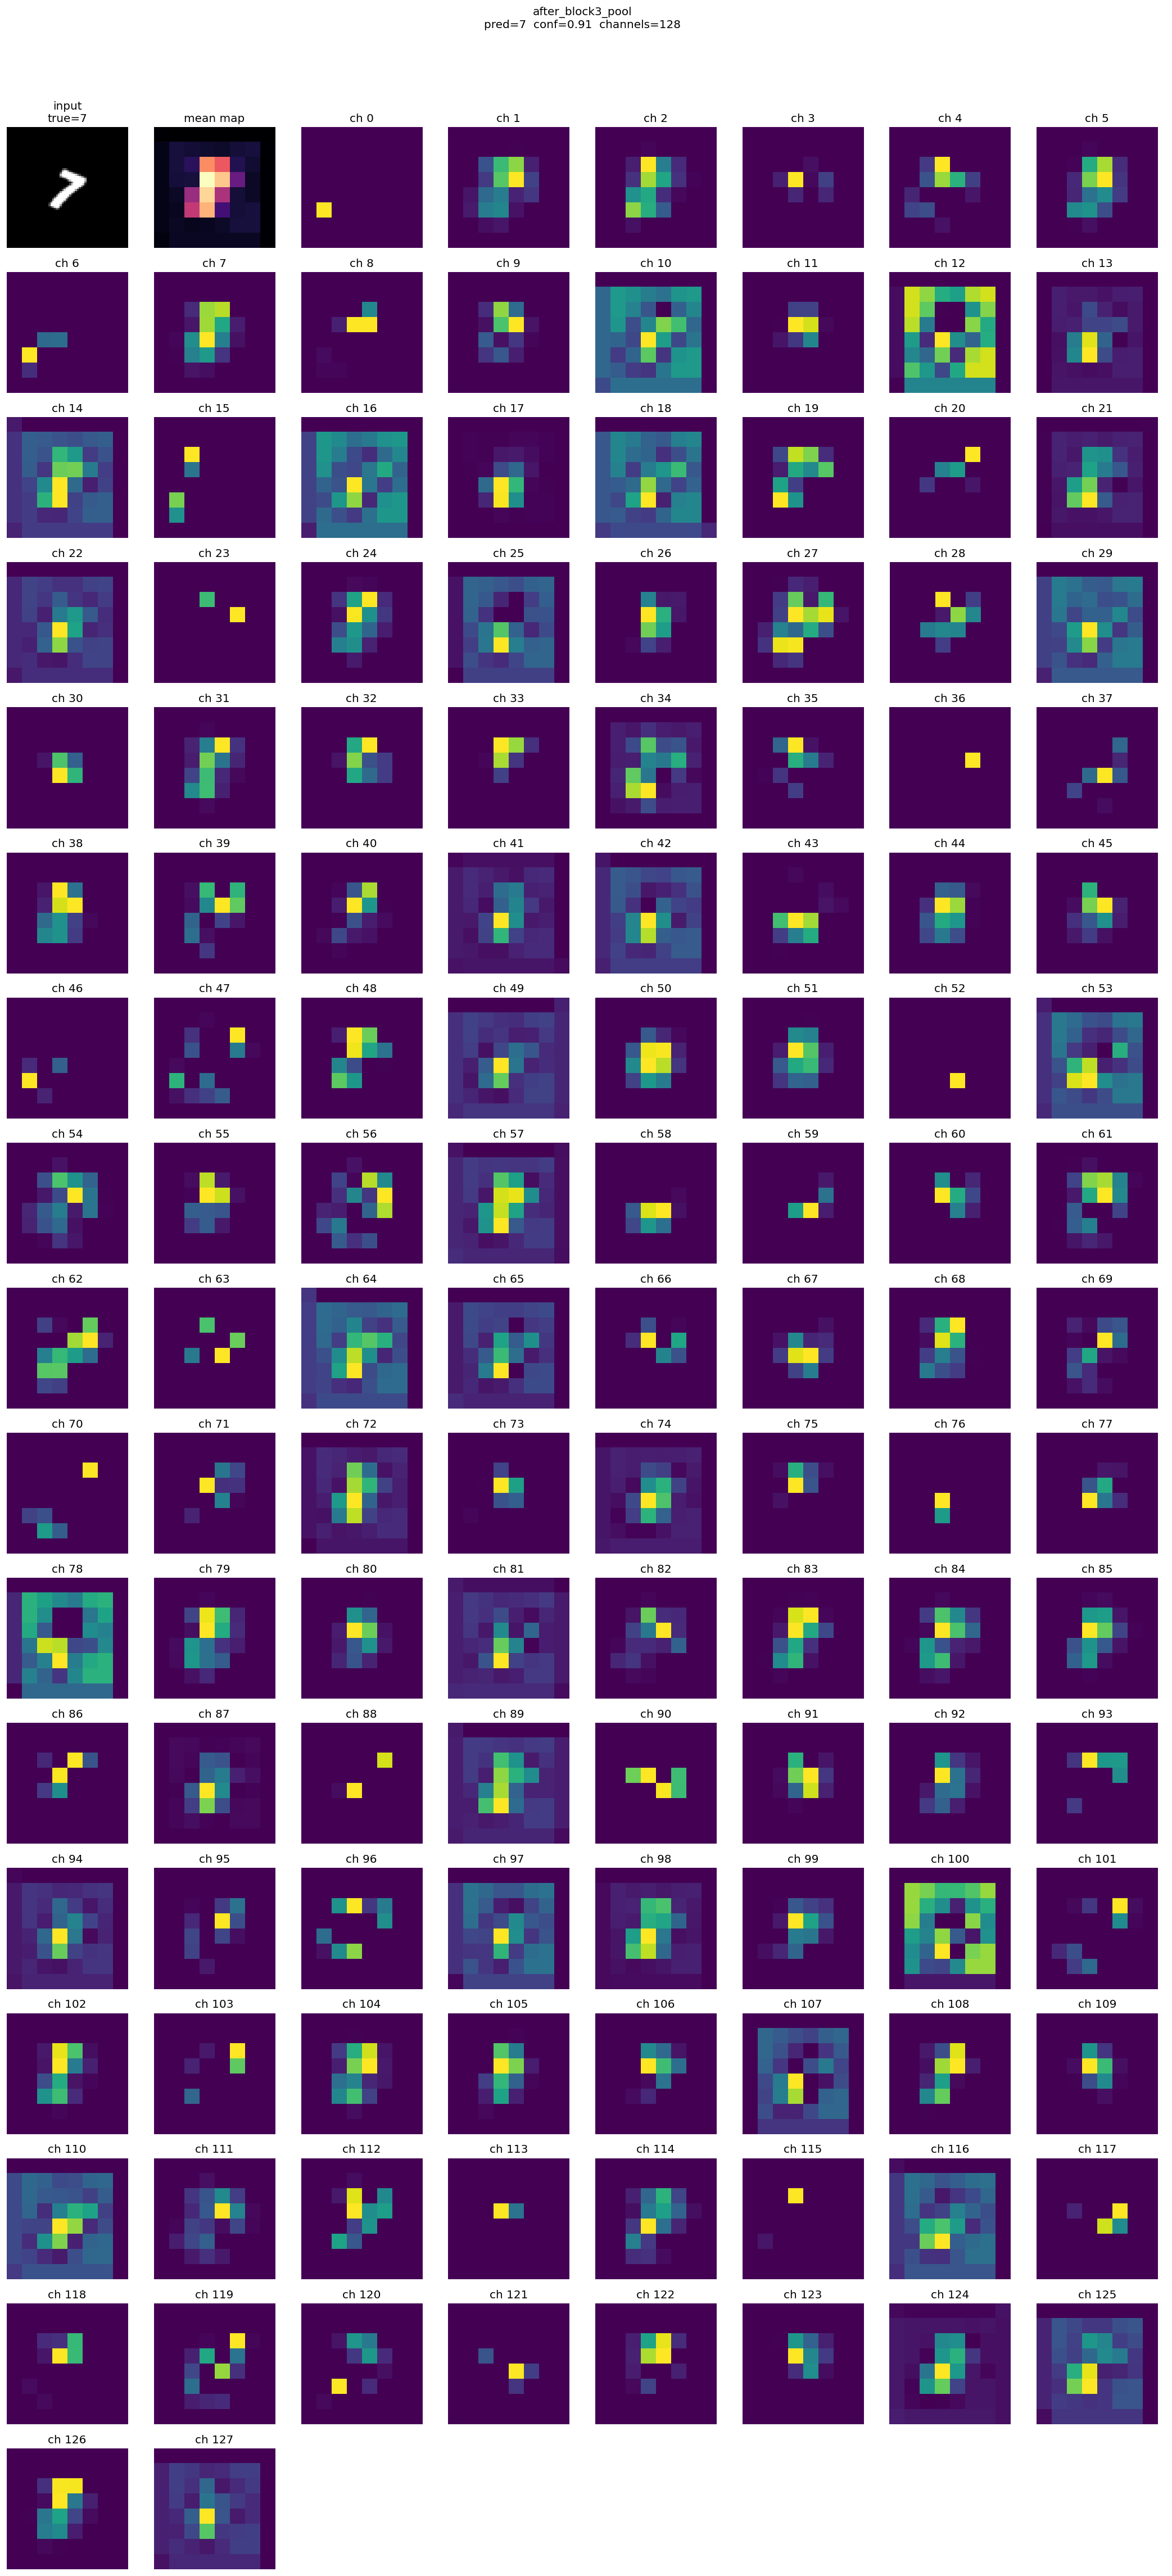

In [15]:
plot_intermediate_activations(
    model,
    val_dataset,
    example_index_1,
    idx_to_class,
    device=device,
    max_channels=None,
)


## Cell 8: Visualize Intermediate Activations For Example 2

This second example is useful because different classes can activate very different channel patterns. Digits often emphasize loops, open curves, and stroke endings, while action symbols may produce more distributed or asymmetric responses. Because all channels are shown, the output may span several large figures per example.


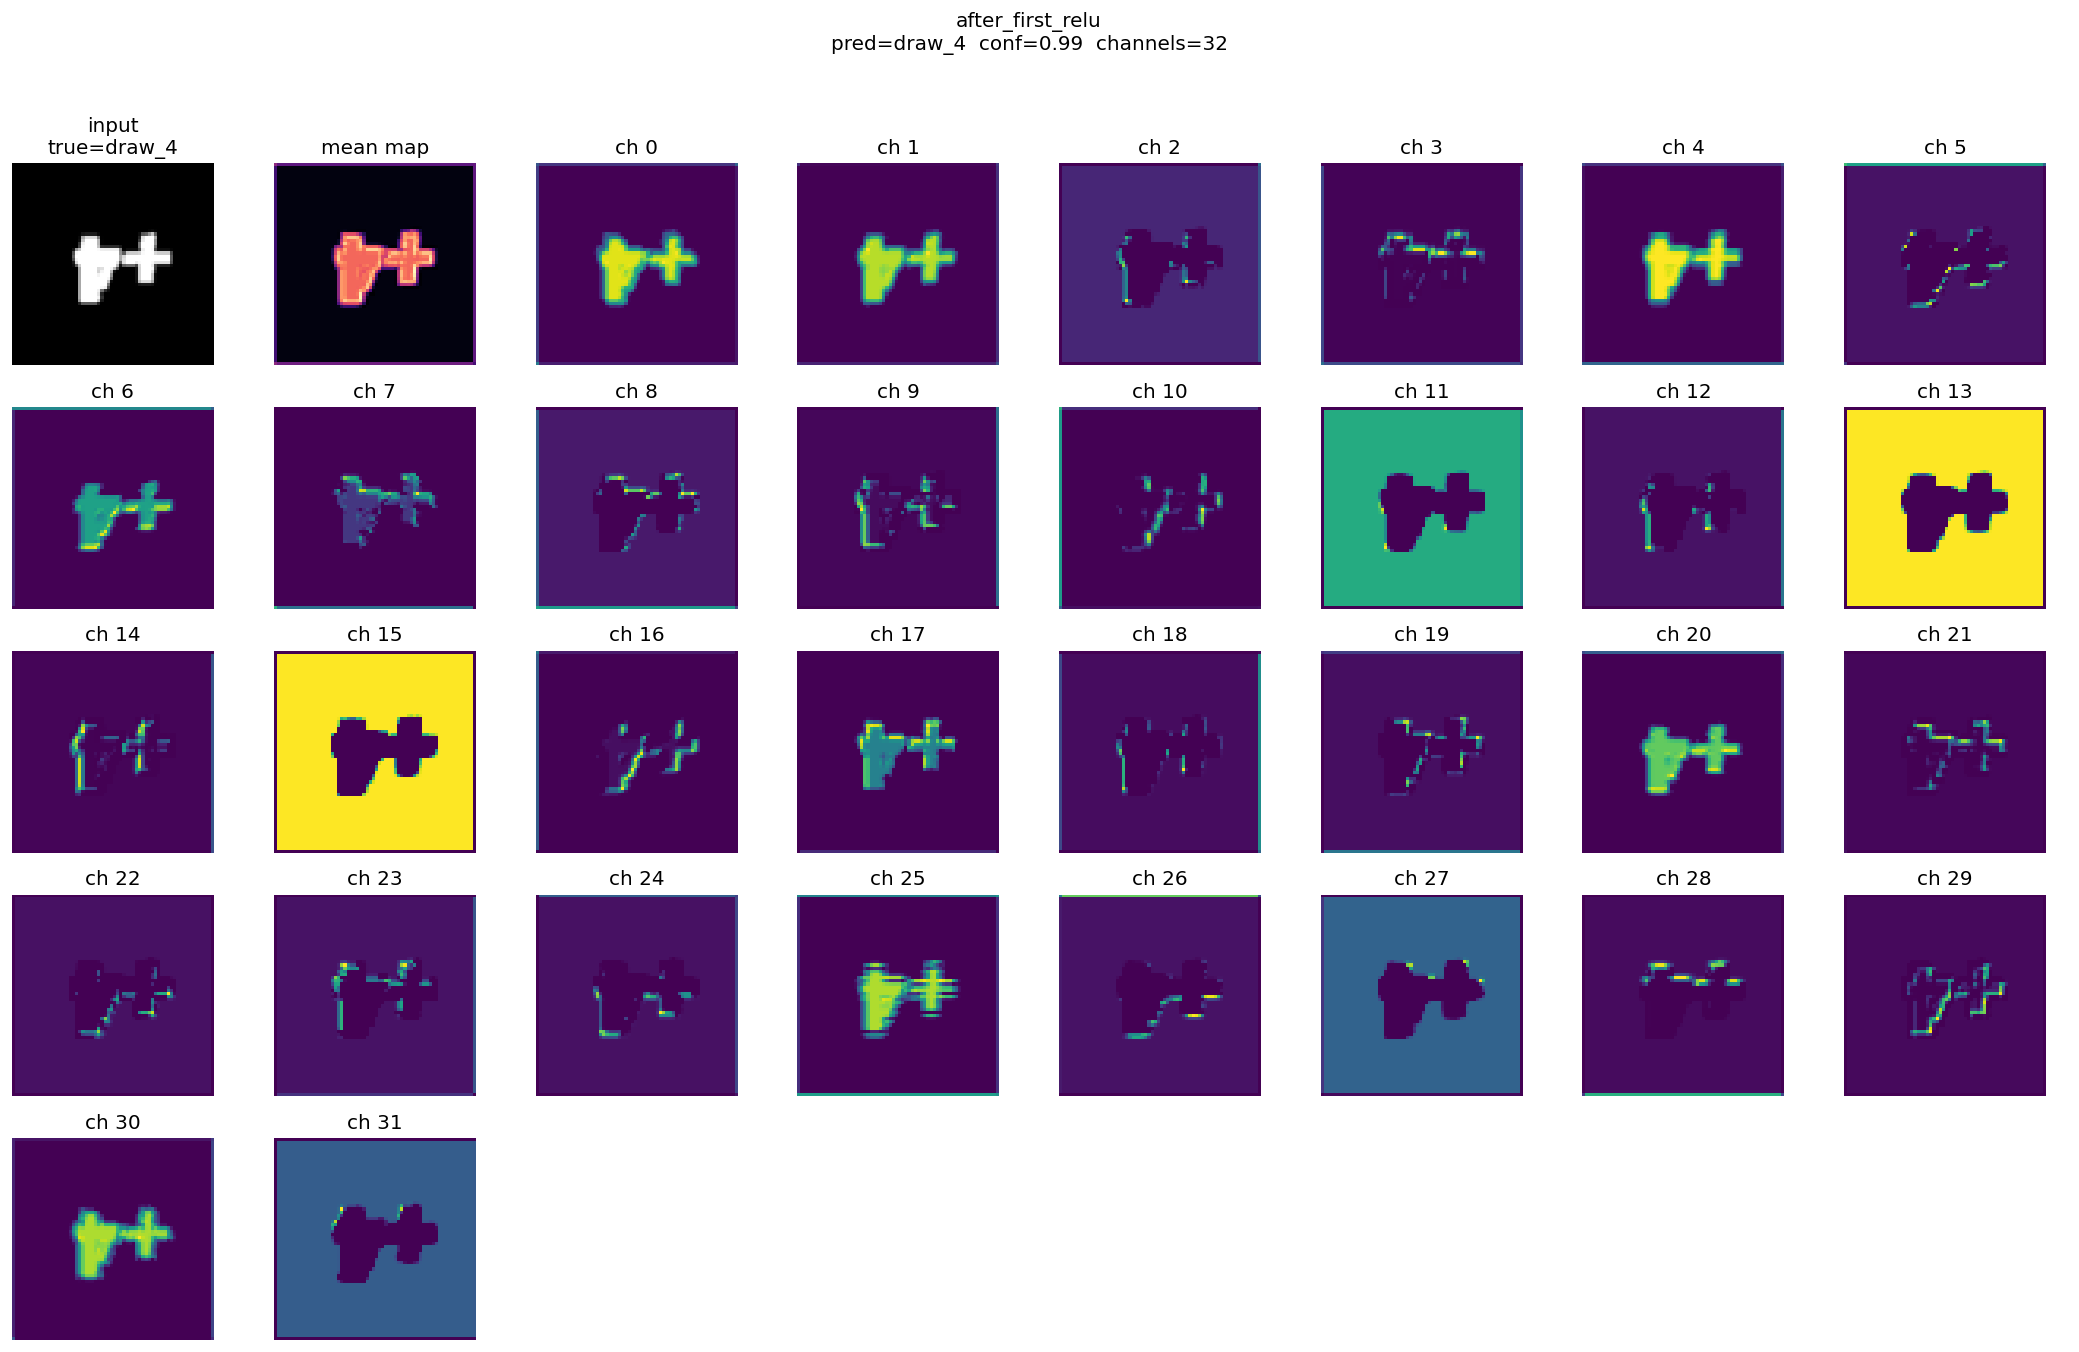

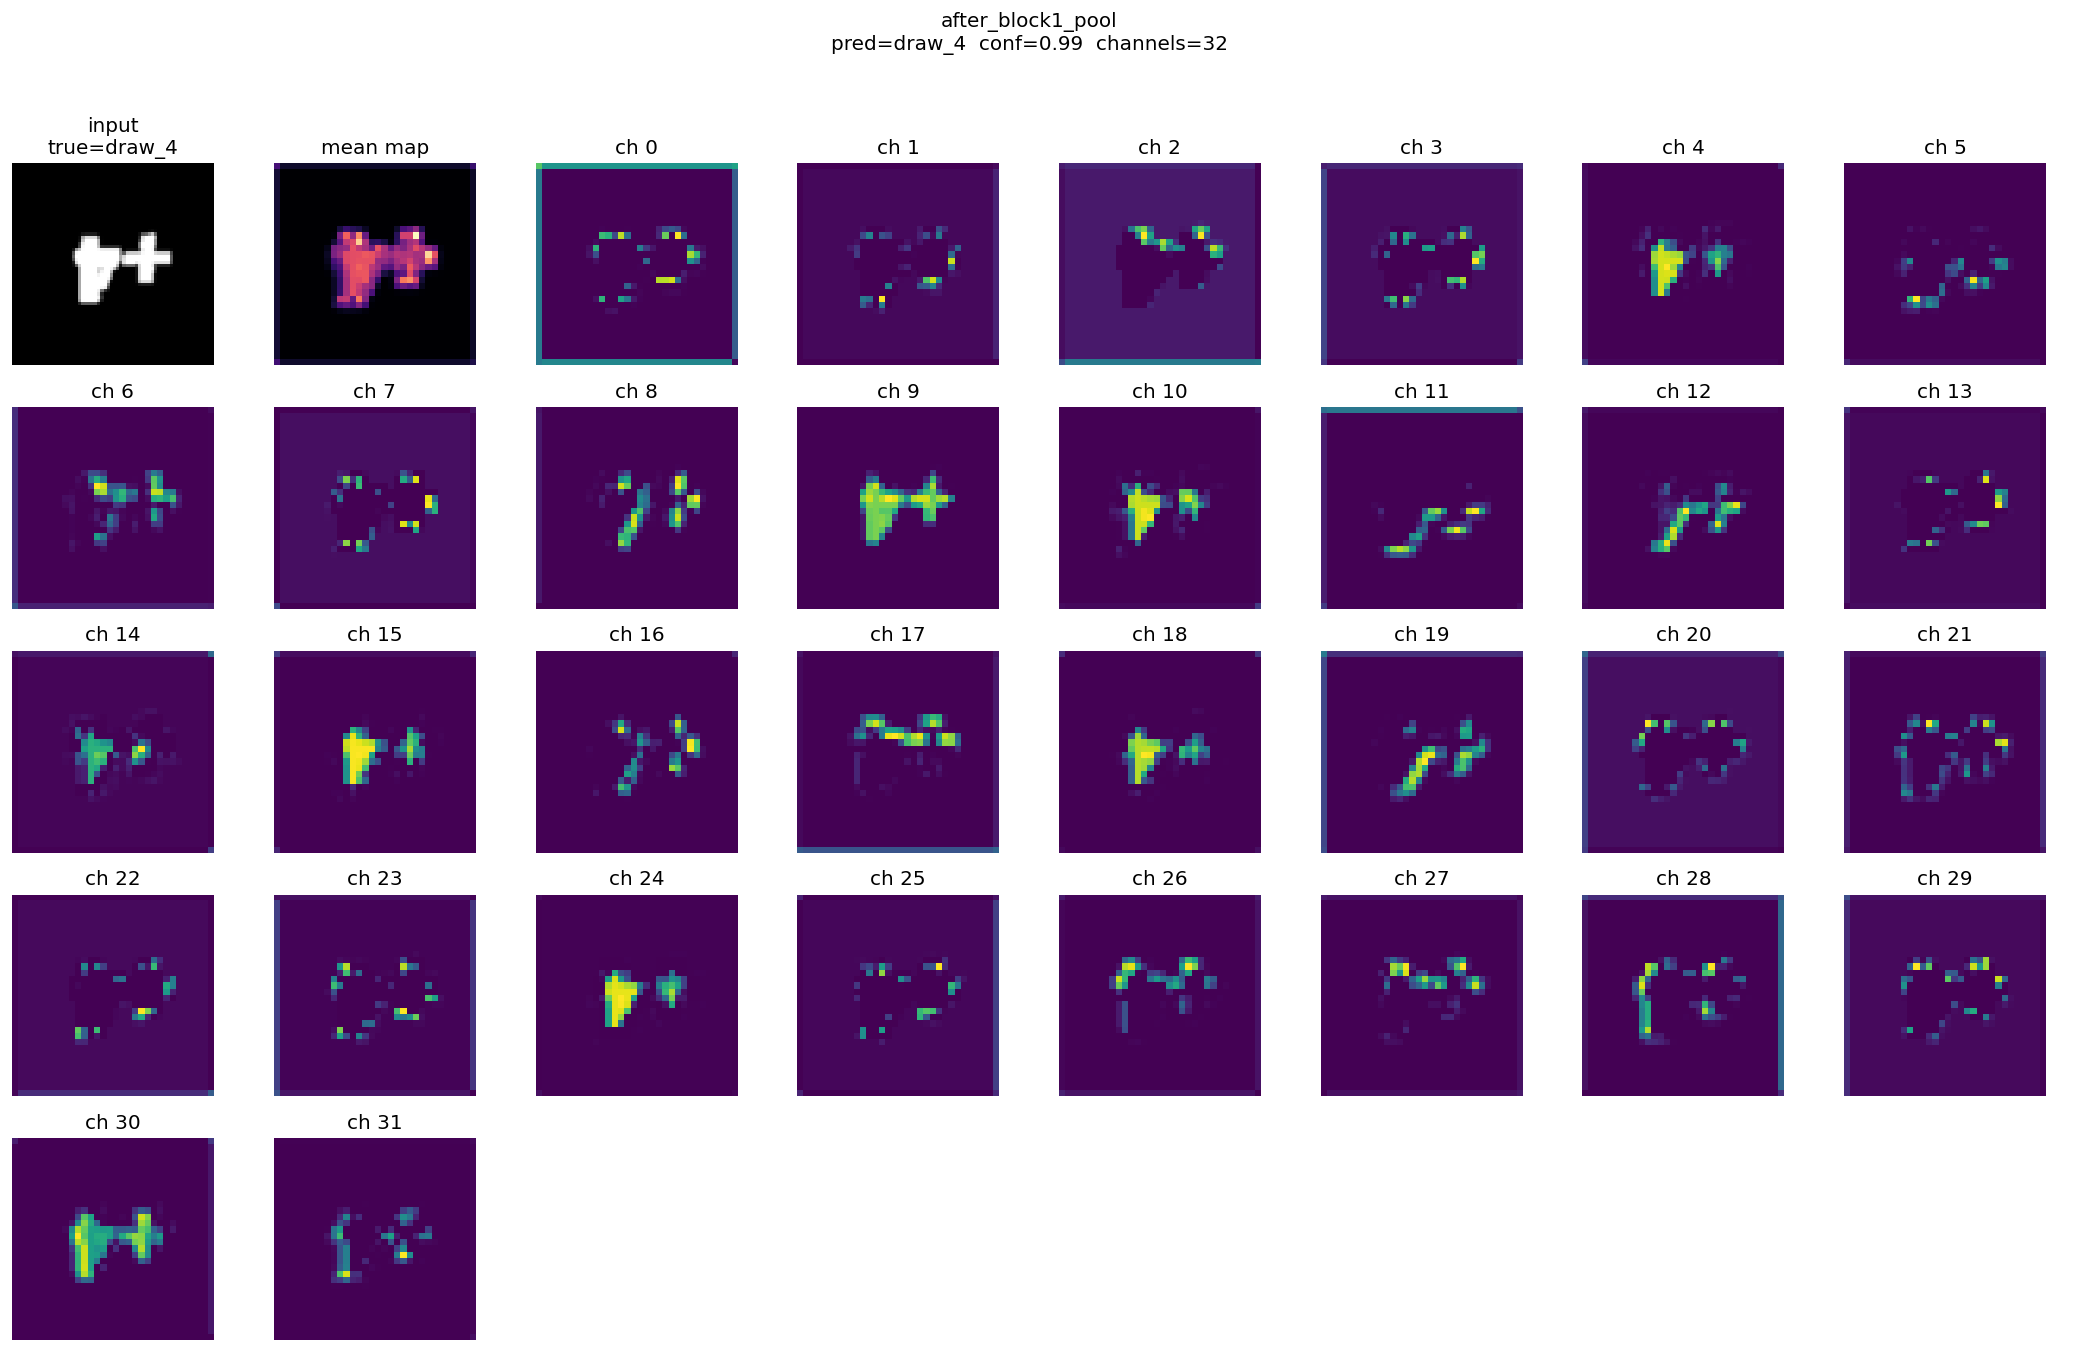

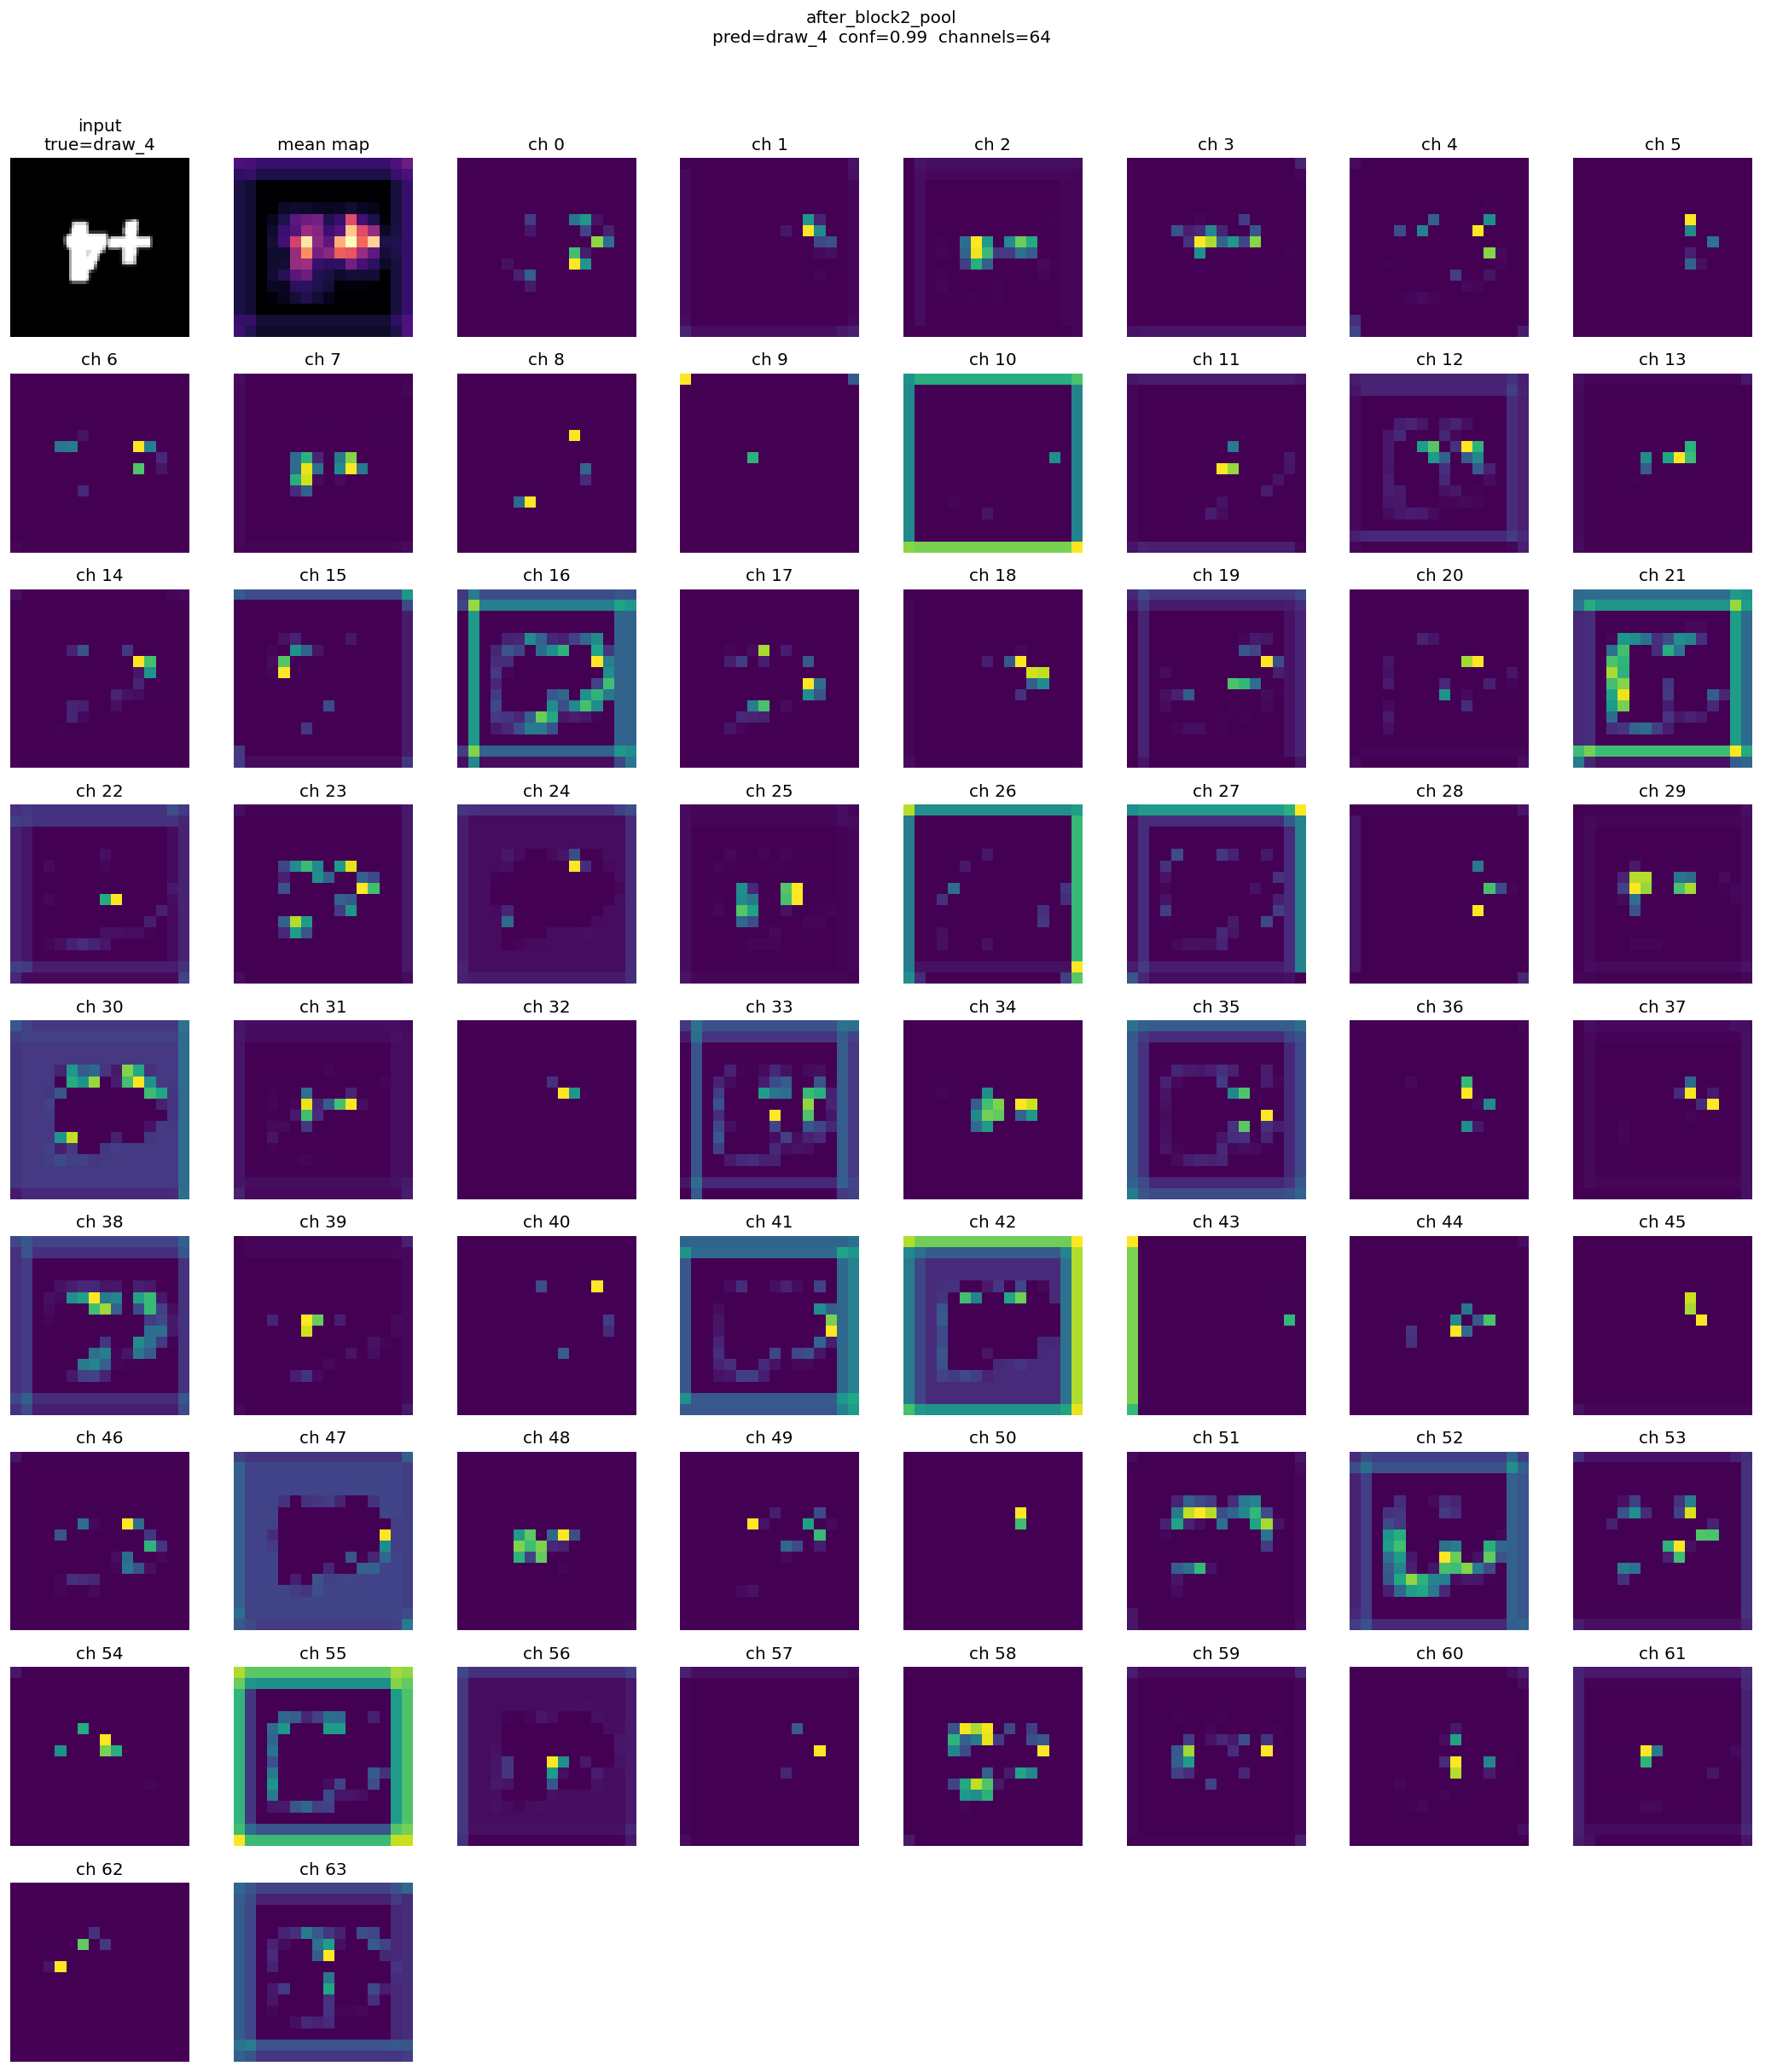

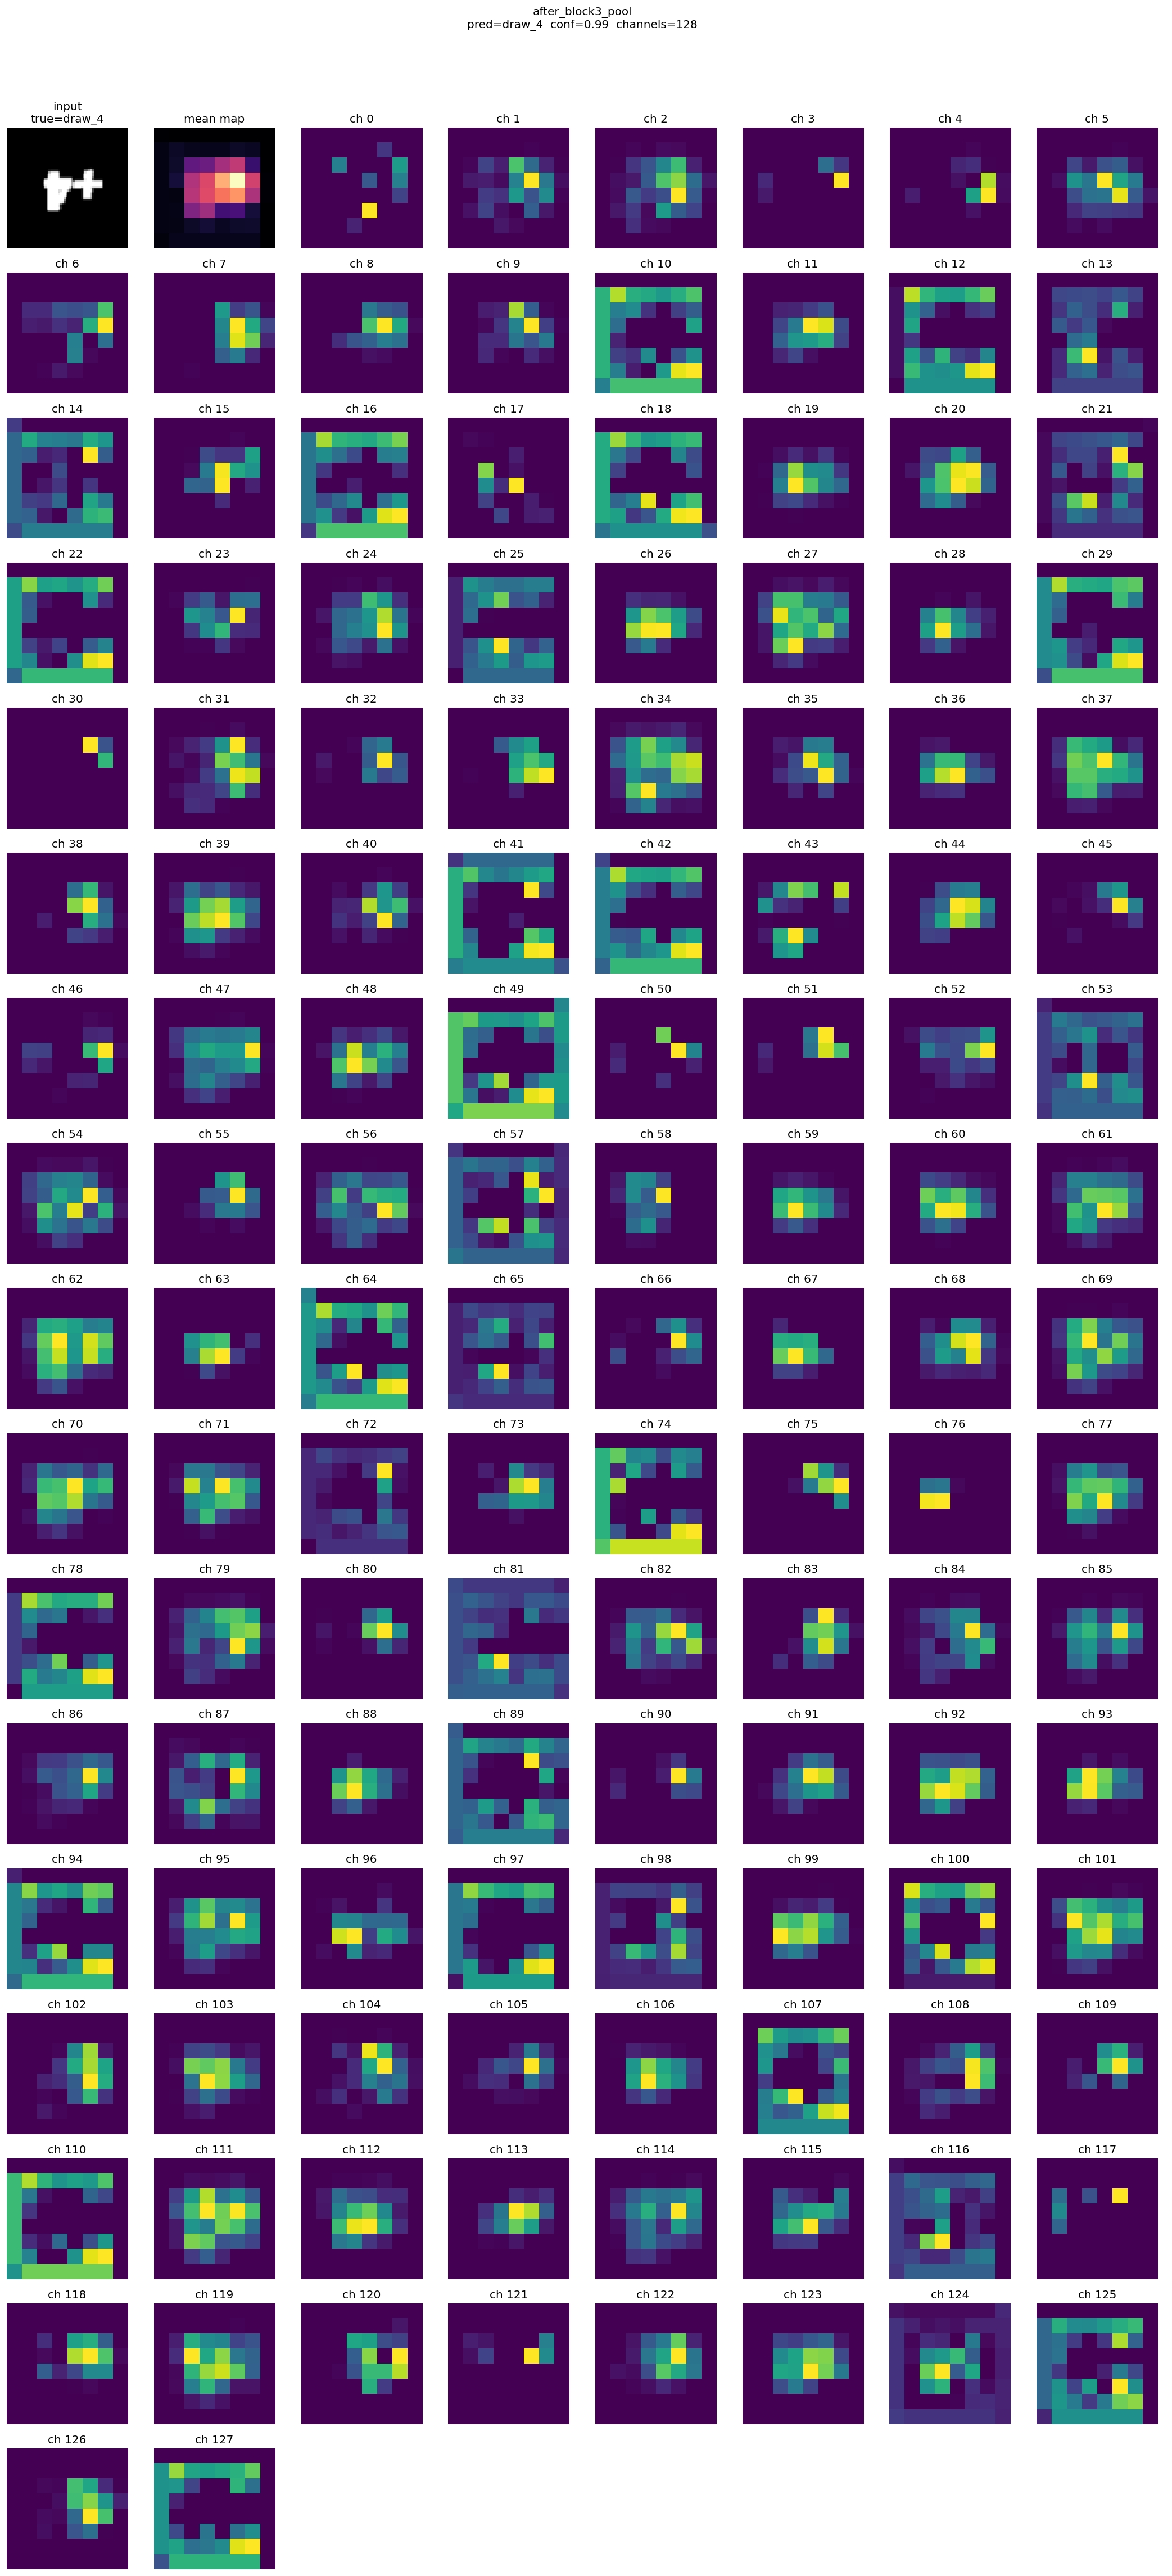

In [7]:
plot_intermediate_activations(
    model,
    val_dataset,
    example_index_2,
    idx_to_class,
    device=device,
    max_channels=None,
)


## Cell 5: Summarize The Main Architectural Numbers

This cell prints a few compact statistics that are easier to cite in a report than the full model dump. In particular, the parameter count helps justify that the network is intentionally lightweight rather than over-engineered.


In [8]:
print(summary)

{'total_parameters': 141423, 'trainable_parameters': 141423, 'conv_blocks': 3}


## Data Processing And Training Behavior

The training split was balanced through augmentation. That choice matters because it prevents the model from becoming biased toward whichever symbols appeared most often in the raw extracted dataset.

Another important detail is that augmented images are re-binarized after rotation and translation. Without that step, interpolation would create gray artifacts that do not match the original clean black-and-white symbol style.


## Cell 9: Visualize Class Balance And Training Curves

This cell combines two diagnostics.

- The bar charts verify that the training split is almost perfectly balanced.
- The training-history plots show whether the network learned steadily and whether validation performance followed training performance.

A stable gap between train and validation curves would suggest good generalization. A widening gap would suggest overfitting.


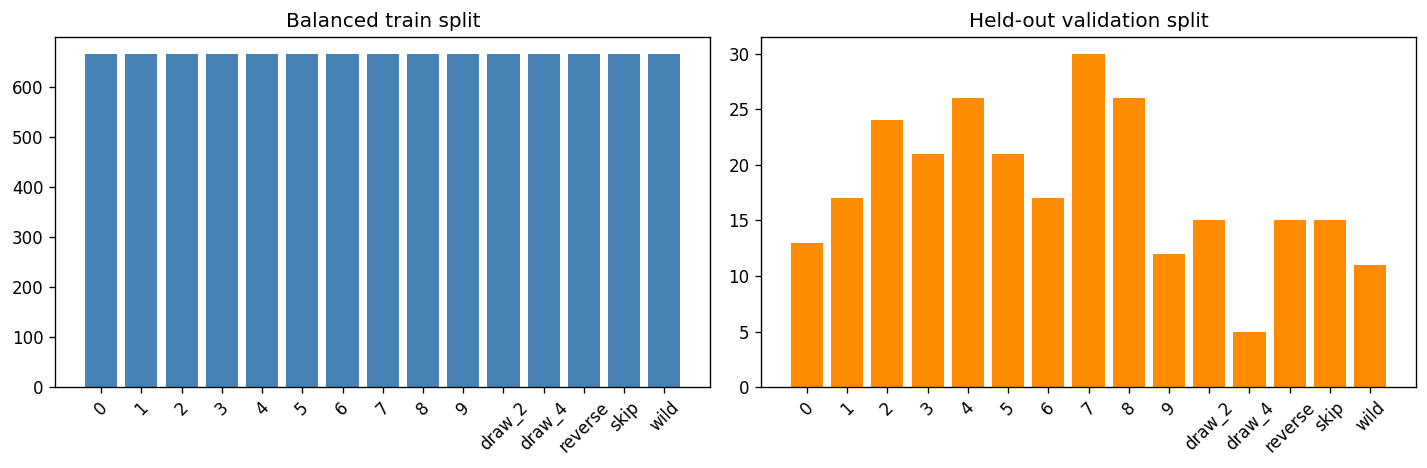

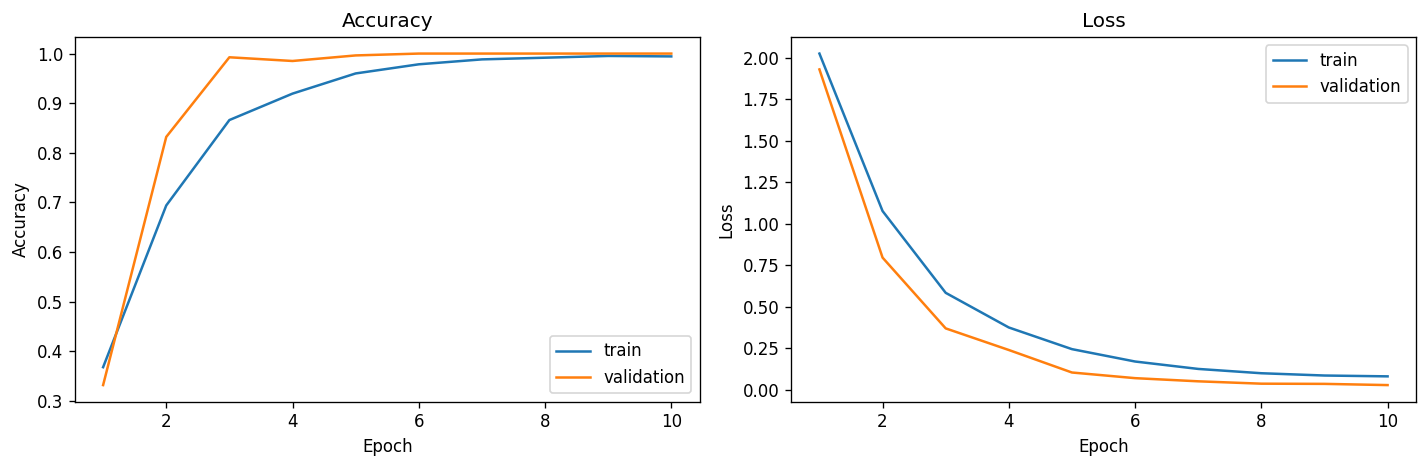

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(split_class_counts(train_labels).keys(), split_class_counts(train_labels).values(), color="steelblue")
axes[0].set_title("Balanced train split")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(split_class_counts(val_labels).keys(), split_class_counts(val_labels).values(), color="darkorange")
axes[1].set_title("Held-out validation split")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()

plot_history(history)

## Cell 10: Evaluate The Validation Set

This cell runs the saved model on the full validation set and computes:

- prediction logits,
- predicted labels,
- prediction confidence,
- overall accuracy,
- and a confusion matrix.

The confusion matrix is especially useful because it shows *which* classes are confused, not just *how often* the model is right.


Validation accuracy: 1.0000
Mean confidence: 0.9720


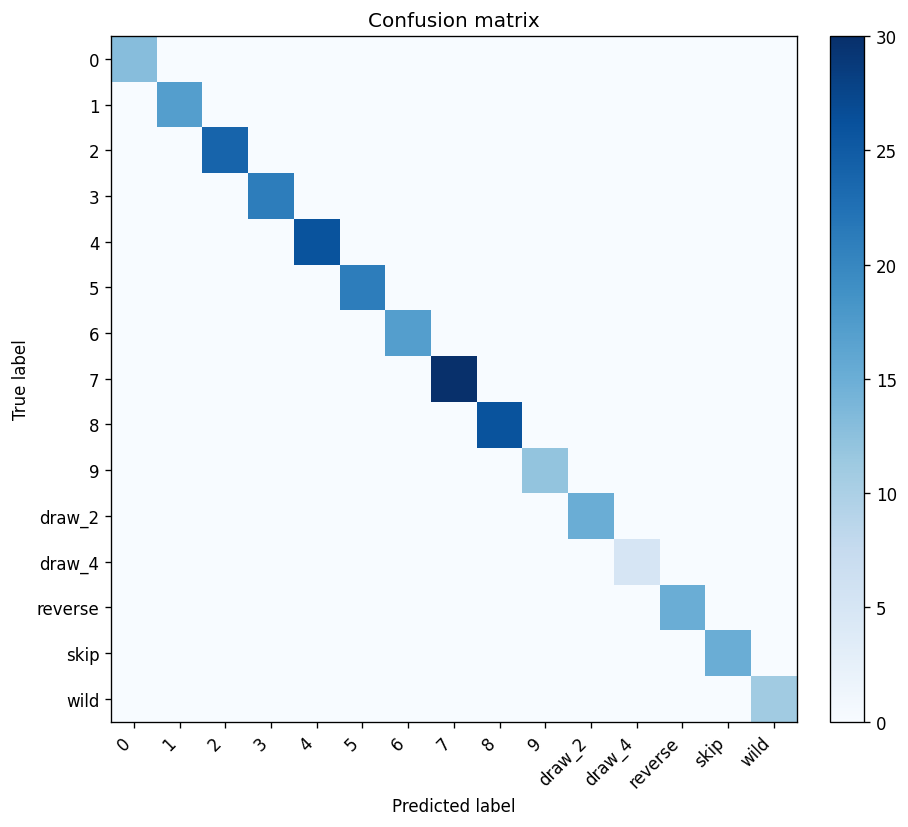

In [10]:
logits, labels, predictions, confidences = collect_predictions(model, val_dataset, batch_size=128, device=device)
matrix = confusion_matrix_from_predictions(labels, predictions, num_classes=len(idx_to_class))
accuracy = float((predictions == labels).float().mean())

print(f"Validation accuracy: {accuracy:.4f}")
print(f"Mean confidence: {float(confidences.mean()):.4f}")
plot_confusion_matrix(matrix, idx_to_class)

## What The CNN Has Learned

We now inspect the representation at three complementary levels.

1. **First-layer filters** show the smallest visual structures the model reacts to.
2. **Penultimate-layer embeddings** show how the model organizes samples in feature space before the final decision.
3. **Grad-CAM** highlights the image regions that most influenced a given class score.

Together, these views help answer whether the model is learning meaningful symbol structure.


## Cell 11: Visualize First-Layer Filters

This cell plots a subset of the learned kernels from the first convolution.

In a healthy classifier, these filters usually resemble edge, contrast, or stroke detectors. If the network had learned nothing useful, the kernels would often look noisy or redundant.


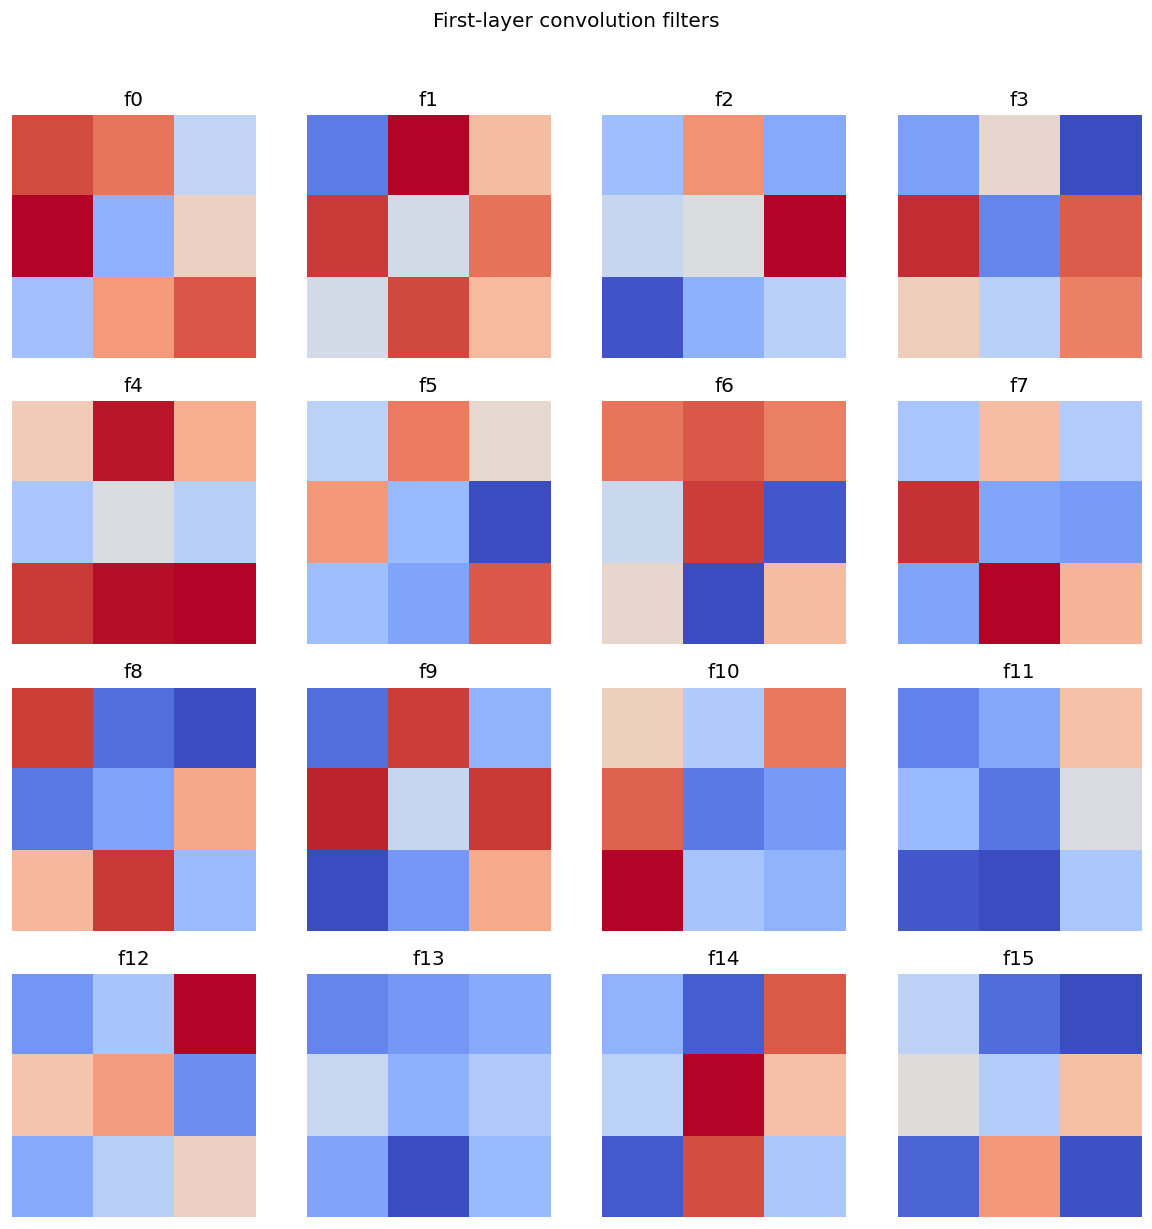

In [11]:
plot_first_layer_filters(model, max_filters=16)

## Cell 12: Project The Penultimate Features To 2D

This cell extracts the `128`-dimensional feature vector produced just before the final linear classifier, then projects those vectors to two dimensions using PCA followed by t-SNE.

Interpretation:

- If points from the same class cluster together, the model has built a useful internal representation.
- If different classes overlap strongly, the last classifier layer would have very little separable structure to work with.

So this plot is one of the strongest pieces of evidence that the CNN has learned meaningful symbol features.


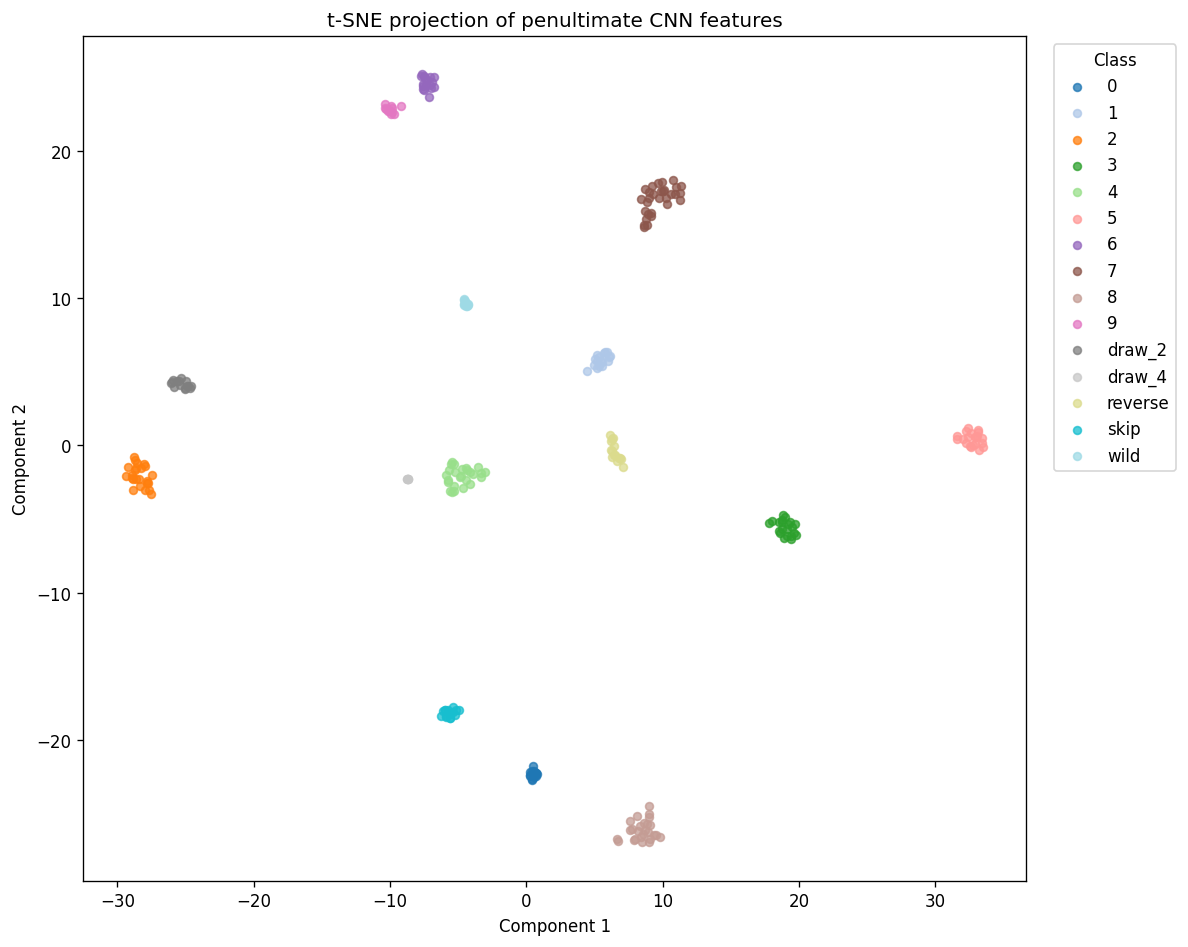

In [12]:
embeddings, embedding_labels, embedding_predictions = extract_embeddings(model, val_dataset, batch_size=128, device=device)
points_2d = project_embeddings(embeddings, seed=42)
plot_embedding_projection(points_2d, embedding_labels, idx_to_class)

## Cell 13: Grad-CAM On Validation Examples

This cell computes Grad-CAM heatmaps for a few confidently correct validation samples.

Grad-CAM works by backpropagating the score of the predicted class into the last convolutional feature maps. In practice, it answers the question: *which spatial regions were most responsible for this decision?*

For this task, we want the heatmaps to concentrate on the symbol strokes themselves rather than on corners, empty margins, or random noise.


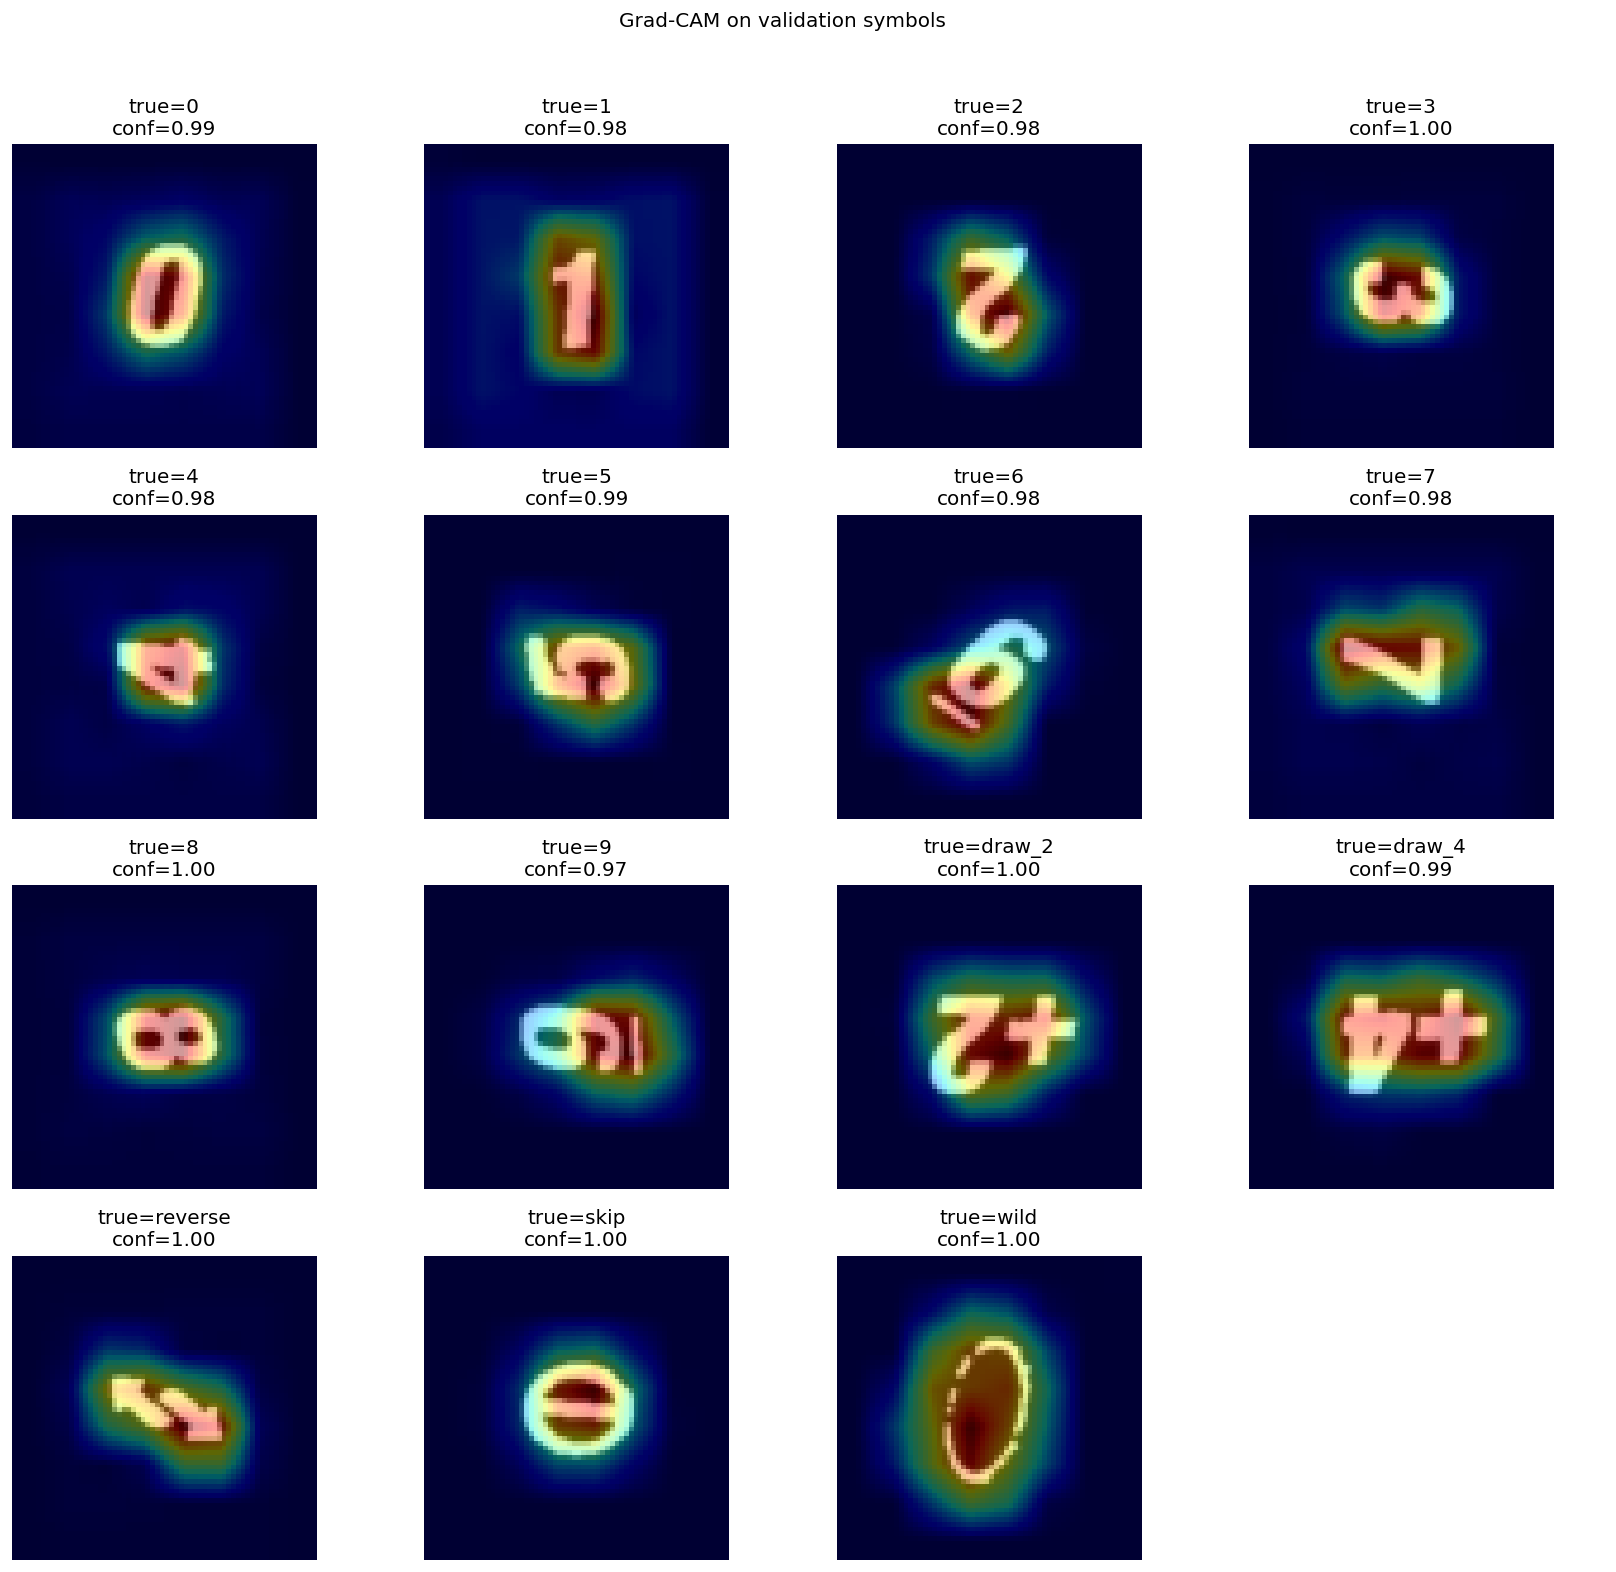

In [13]:
plot_gradcam_examples(
    model,
    val_dataset,
    idx_to_class,
    labels,
    predictions,
    confidences,
    device=device,
    max_examples=15,
)

## Conclusion

This deep learning component is well matched to the UNO symbol-classification task.

- The architecture is intentionally small and uses convolution where it matters most.
- The preprocessing and augmentation encode sensible invariances.
- The training curves and confusion matrix indicate strong validation behavior.
- The filters, embeddings, and Grad-CAM views show that the network learns structured symbol features across layers, from local strokes to class-level patterns.

That is the main interpretability takeaway: the model is not just producing good scores, it is doing so through representations that are visually consistent with the task.
